# AIVLE스쿨 2차 미니프로젝트: 신규 아파트 주차 수요 예측

<img src = "https://github.com/Jangrae/img/blob/master/parking.png?raw=true" width=800, align="left"/>

# 단계 3: 모델링

## [미션]

- 모델링을 수행합니다.
    - 전처리를 추가로 진행합니다.
    - 4개 이상의 알고리즘을 사용해 모델링을 수행합니다.
    - 각 모델에 대해 성능 튜닝을 수행합니다.
    - 성능을 비교해 최선의 모델을 선정합니다.
- 데이터 파이프라인 함수를 만듭니다.
- 새로운 데이터를 읽어와 예측을 수행합니다.

## 1. 환경설정

### (1) 로컬 수행(Anaconda)

- project 폴더에 필요한 파일들을 넣고, 본 파일을 열었다면, 별도 경로 지정이 필요하지 않습니다.

In [1]:
# 기본 경로
path = './'

### (2) 구글 콜랩 수행

- 구글 콜랩을 사용중이면 구글 드라이브를 연결합니다.

### (3) 한글 폰트 표시용 라이브러리 설치

### (4) 라이브러리 불러오기

In [6]:
# 기본 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
import os
from tqdm import tqdm

# 모델링용 라이브러리 불러오기
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 기타 라이브러리 불러기기
import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (5) 데이터 불러오기

- joblib.dump() 함수를 사용해 base_data2.pkl 파일을 읽어옵니다.
- 읽어온 데이터를 data 데이터프레임으로 선언하고 기본 정보를 확인합니다.

In [8]:
# 파일 읽어오기
data = joblib.load(path+'base_data1.pkl')

# 확인
data.head()

,단지코드,총세대수,지역,준공연도,건물형태,난방방식,승강기설치여부,실차량수,총면적,임대보증금,임대료,면적10_20,면적20_30,면적30_40,면적40_50,면적50_60,면적60_70,면적70_80
0,C0001,78,서울,2013,계단식,개별가스난방,전체동 설치,109,6023.7683,5.696200e+07,642930.000000,0,0,0,0,2,0,0
1,C0002,35,서울,2013,복도식,개별가스난방,전체동 설치,35,1569.1668,6.306200e+07,470100.000000,0,2,0,0,0,0,0
2,C0003,88,서울,2013,계단식,개별가스난방,전체동 설치,88,7180.1396,7.219000e+07,586540.000000,0,0,0,0,4,0,0
3,C0004,477,서울,2014,복도식,지역난방,전체동 설치,943,47058.9273,1.015167e+08,950305.000000,0,0,0,0,1,0,2
4,C0006,15,서울,2013,복도식,개별가스난방,전체동 설치,21,543.0268,5.522750e+07,340148.333333,3,3,0,0,0,0,0


In [9]:
data.describe()

,총세대수,준공연도,실차량수,총면적,임대보증금,임대료,면적10_20,면적20_30,면적30_40,면적40_50,면적50_60,면적60_70,면적70_80
count,345.000000,345.000000,345.000000,345.000000,3.450000e+02,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000
mean,546.759420,2007.713043,555.431884,37282.661962,2.382737e+07,197729.050210,0.011594,0.272464,0.901449,0.742029,0.831884,0.011594,0.159420
std,432.359538,7.261036,374.640474,29588.197927,2.247481e+07,158760.777669,0.170103,0.678551,1.097896,0.982463,1.303226,0.170103,0.528908
min,1.000000,1992.000000,21.000000,68.930000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,178.000000,2003.000000,258.000000,11293.832100,1.272491e+07,112905.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,491.000000,2008.000000,498.000000,32190.360000,1.930850e+07,172000.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,853.000000,2013.000000,822.000000,56189.979600,2.837700e+07,227564.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000
max,2289.000000,2022.000000,1657.000000,150126.863200,1.898219e+08,950305.000000,3.000000,5.000000,8.000000,8.000000,8.000000,3.000000,3.000000


단변량 분석

100%|████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00,  5.46it/s]


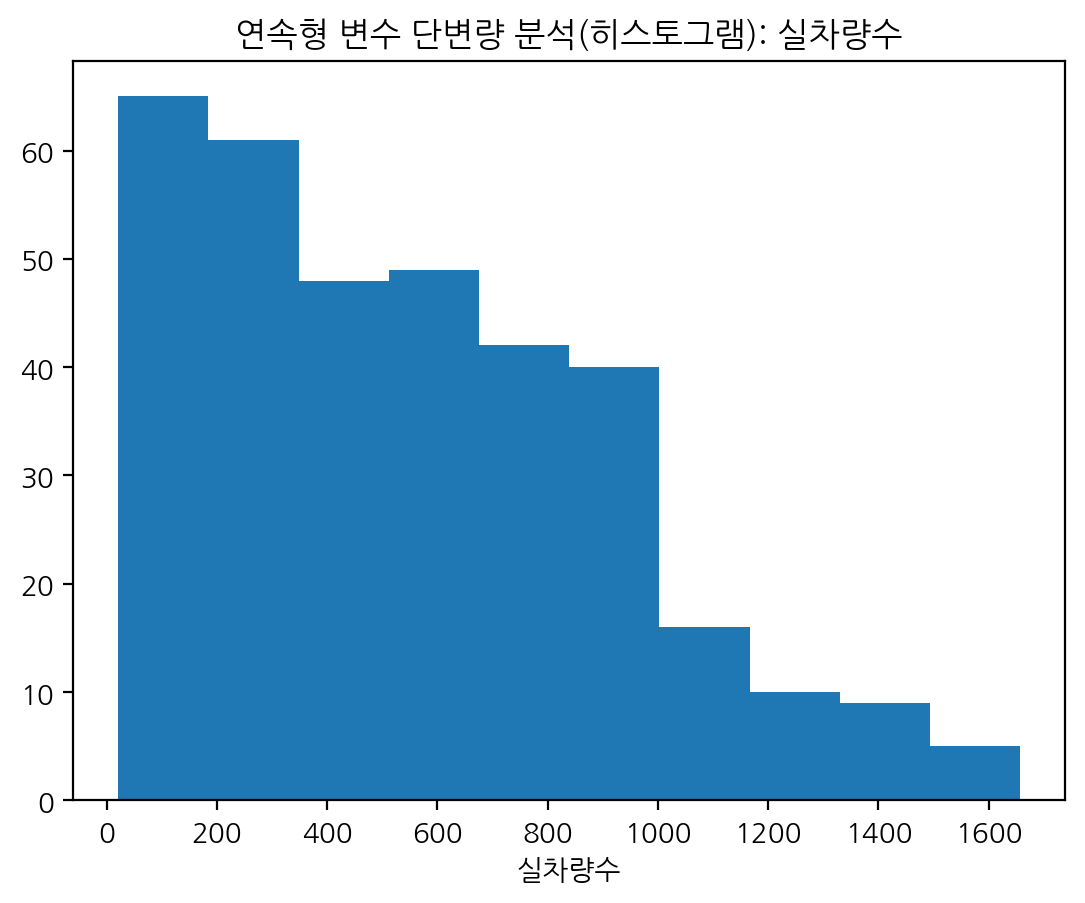

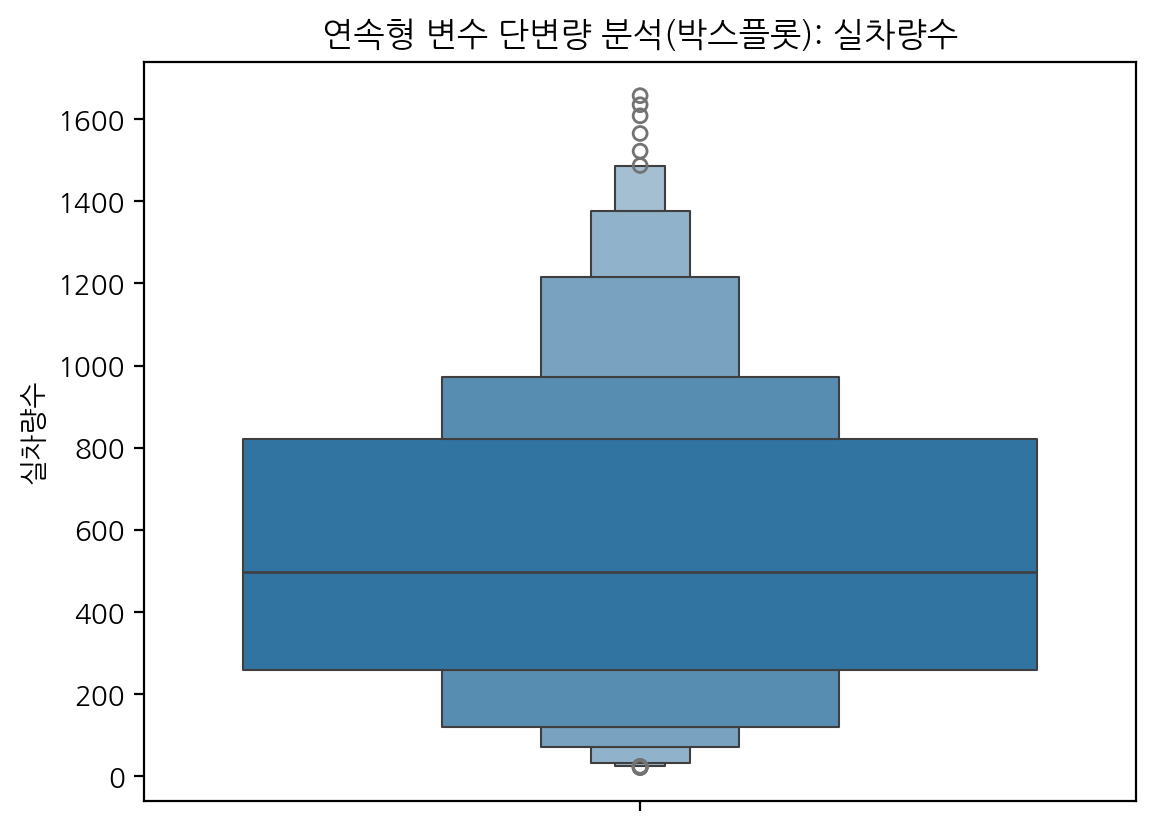

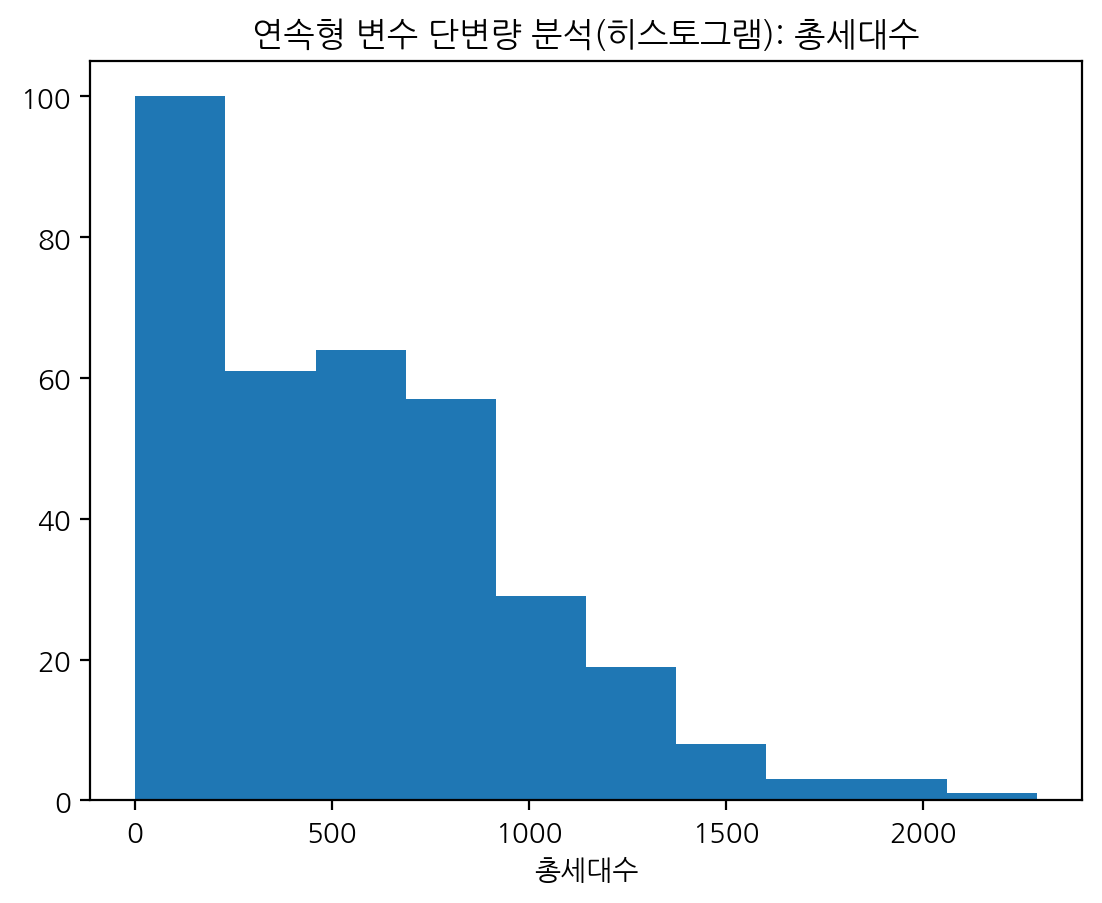

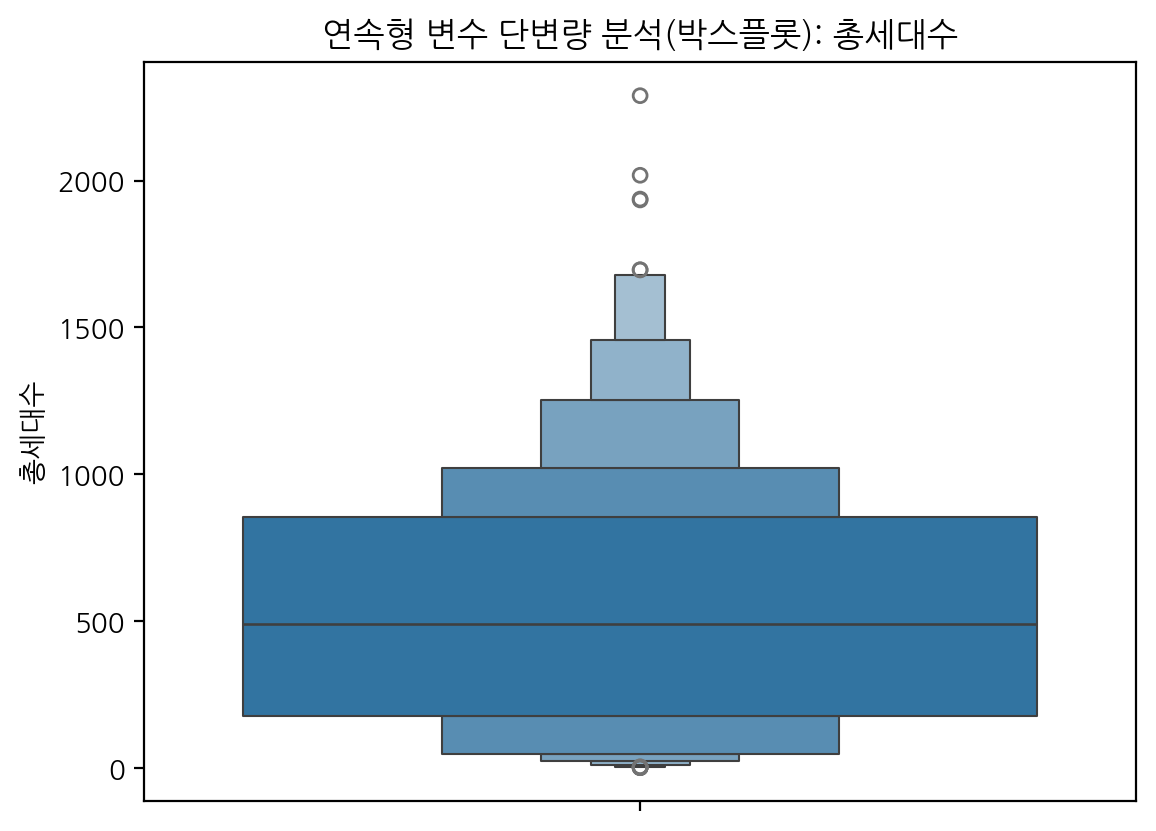

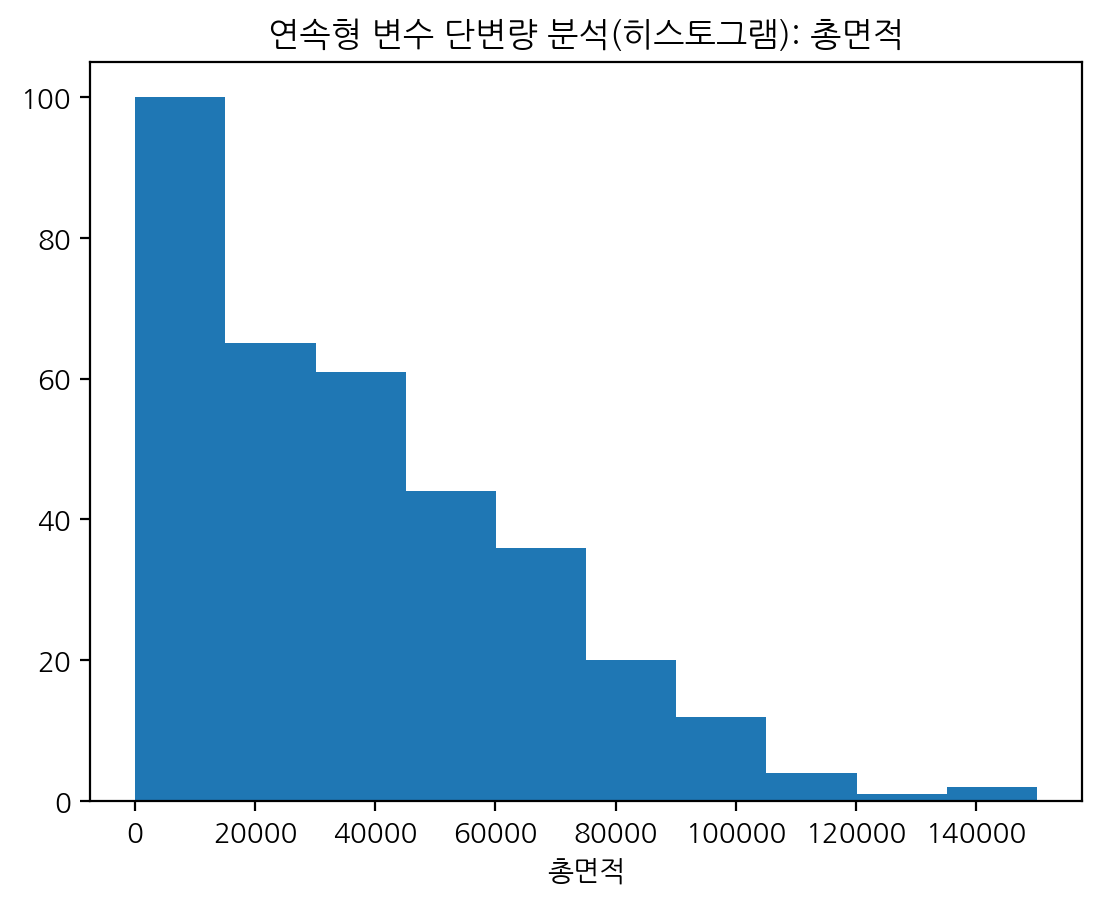

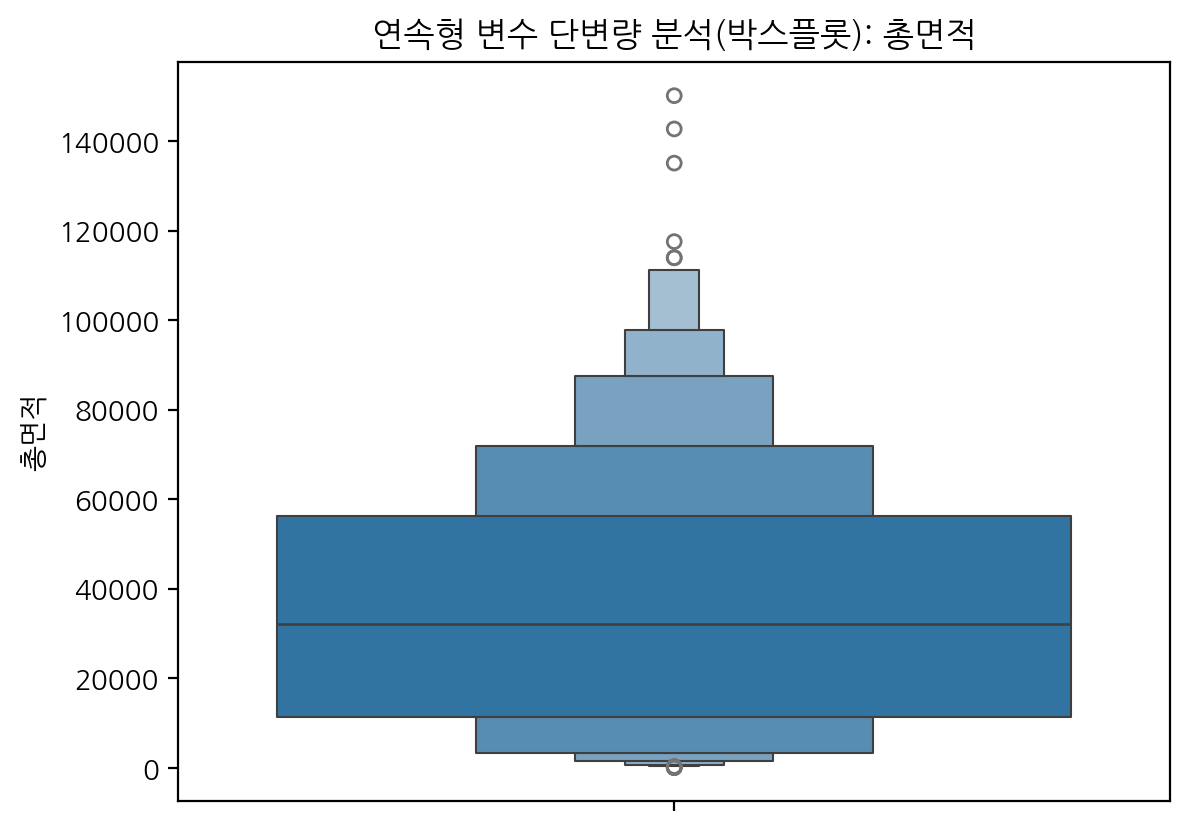

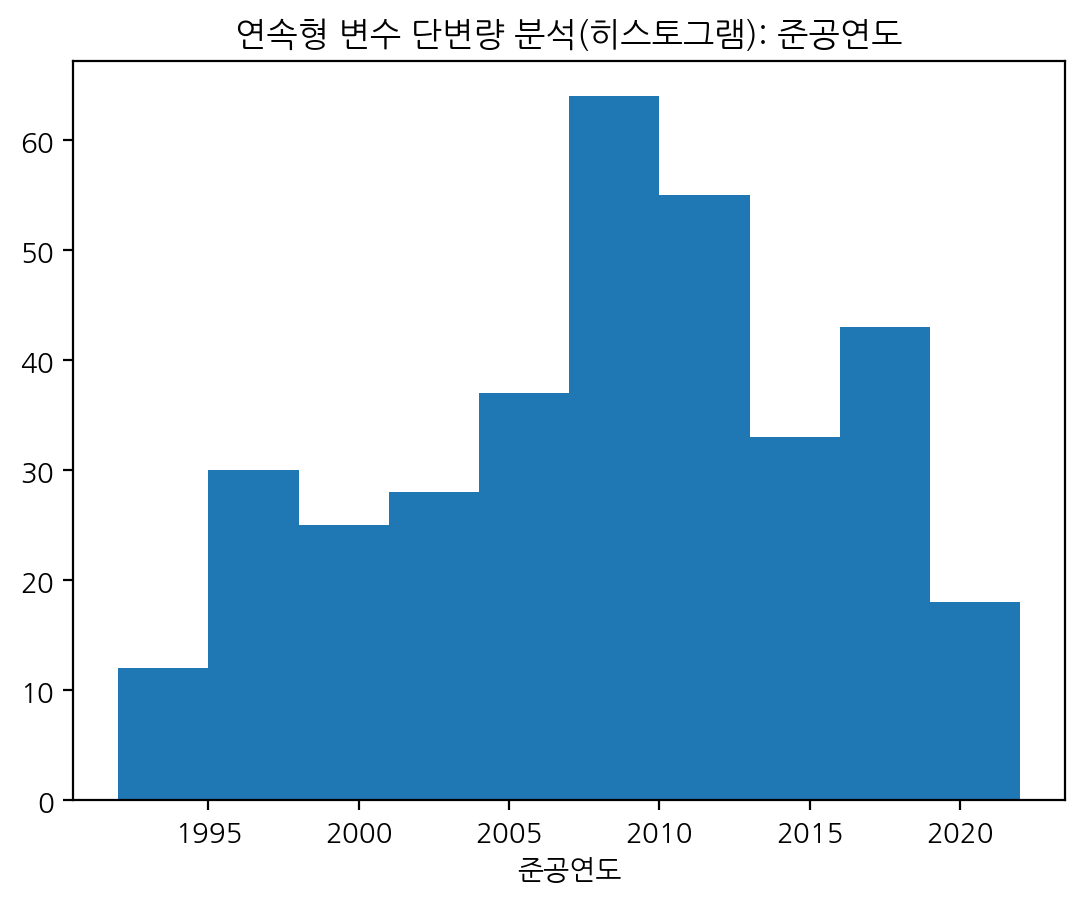

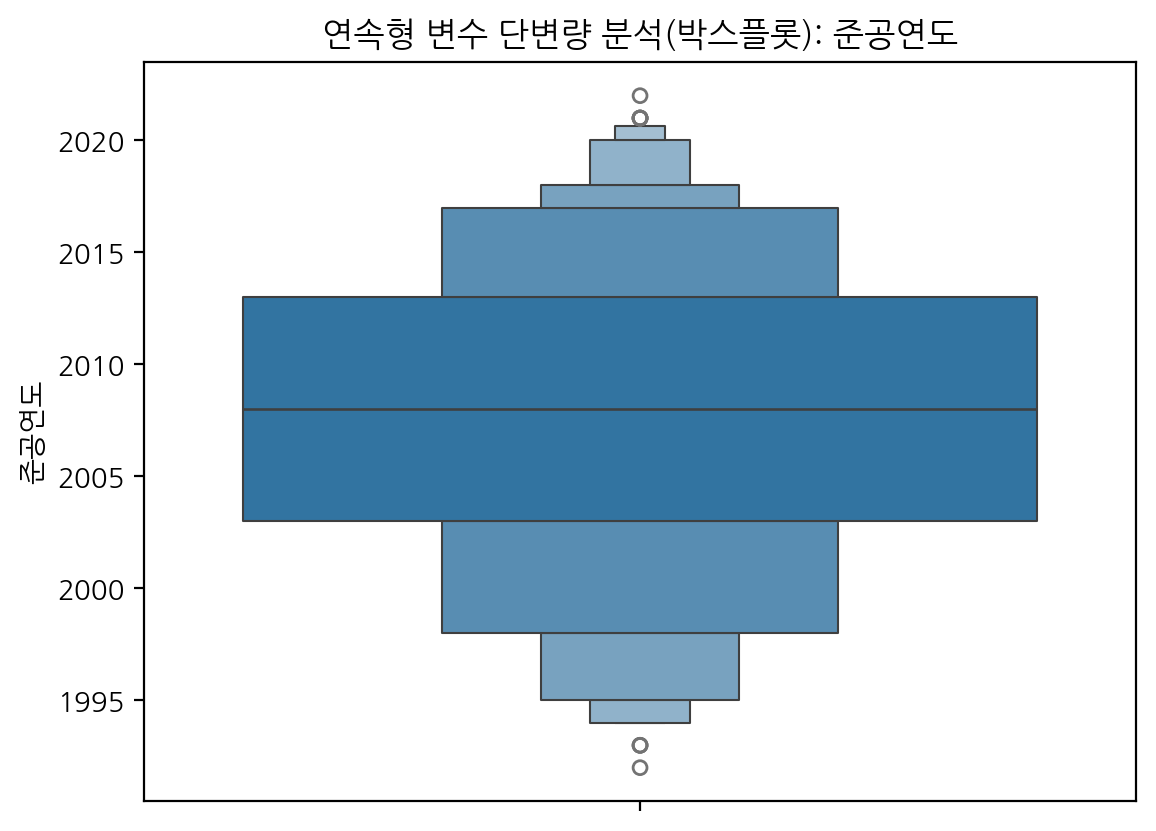

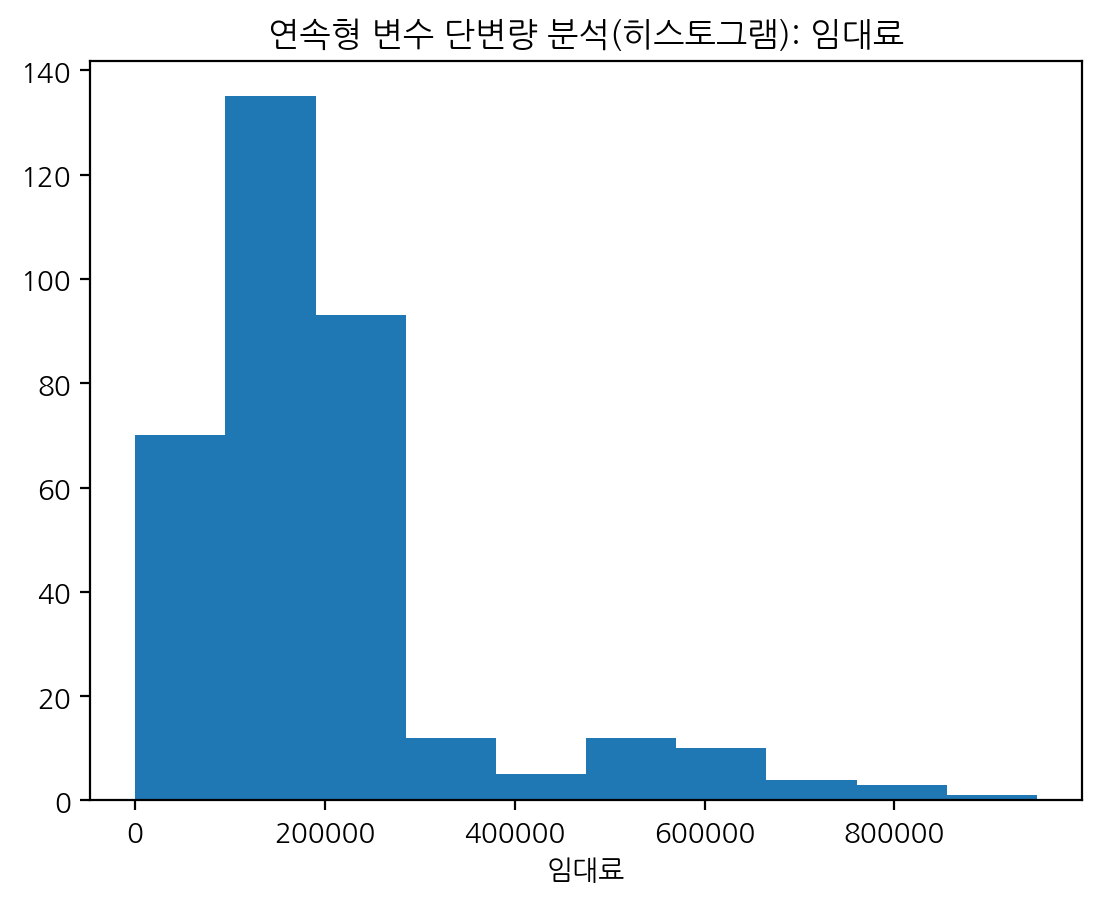

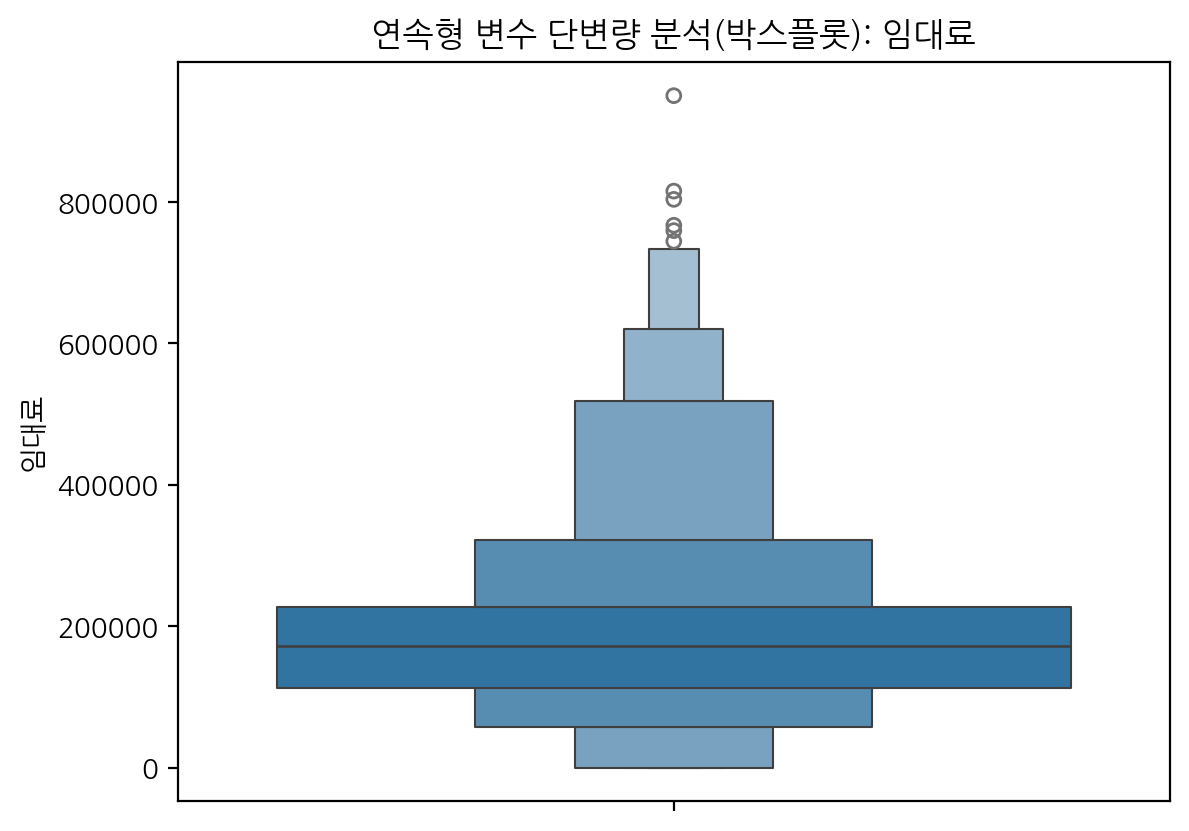

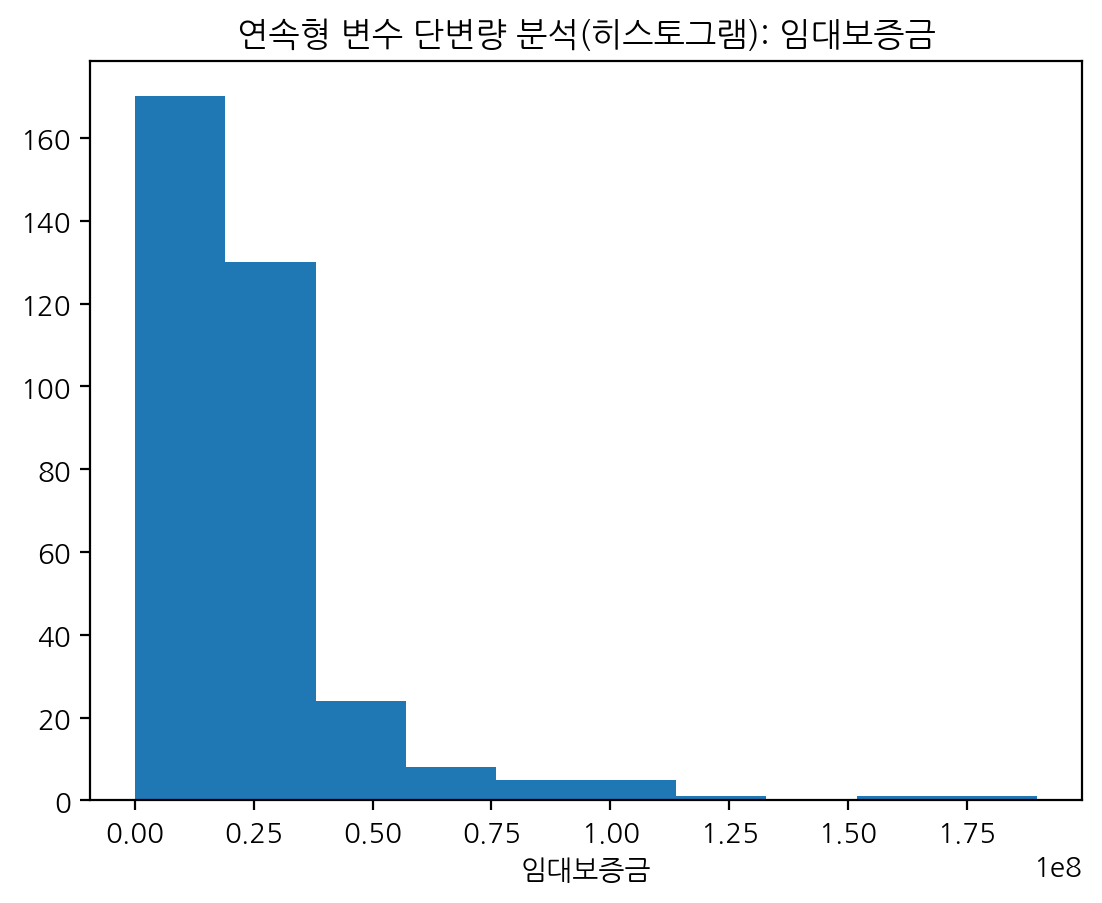

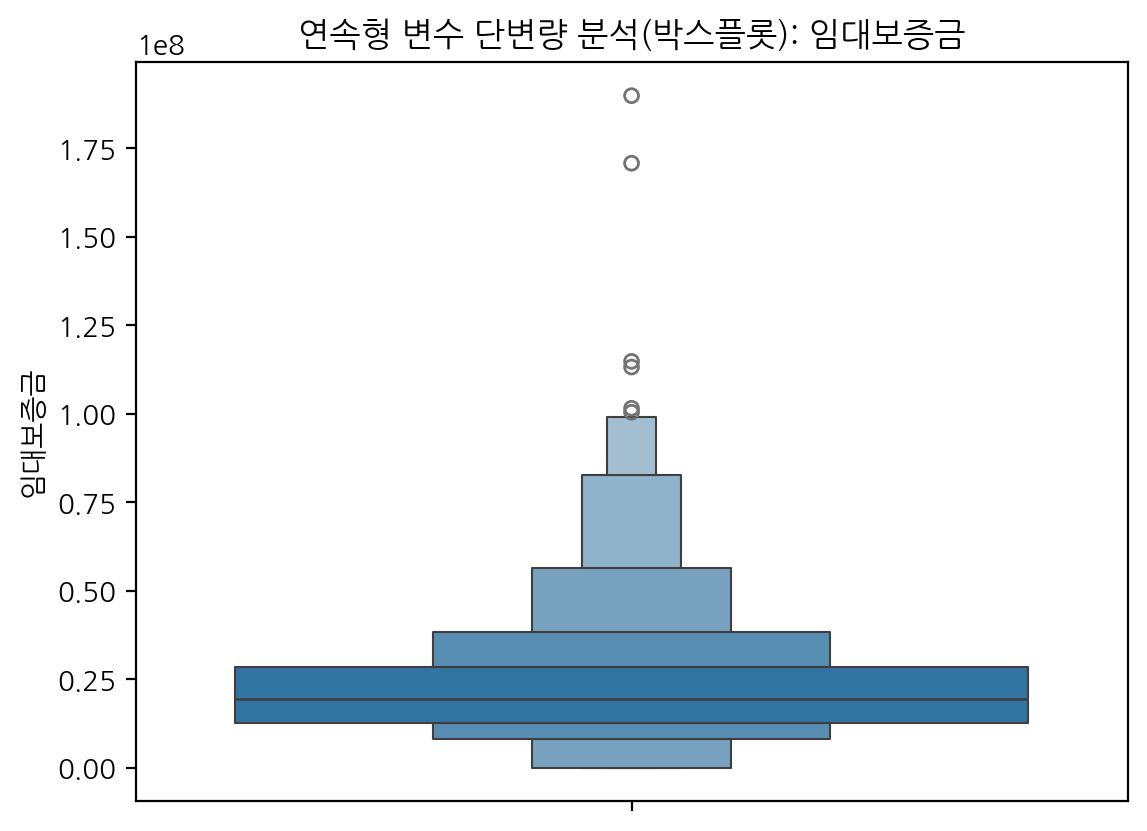

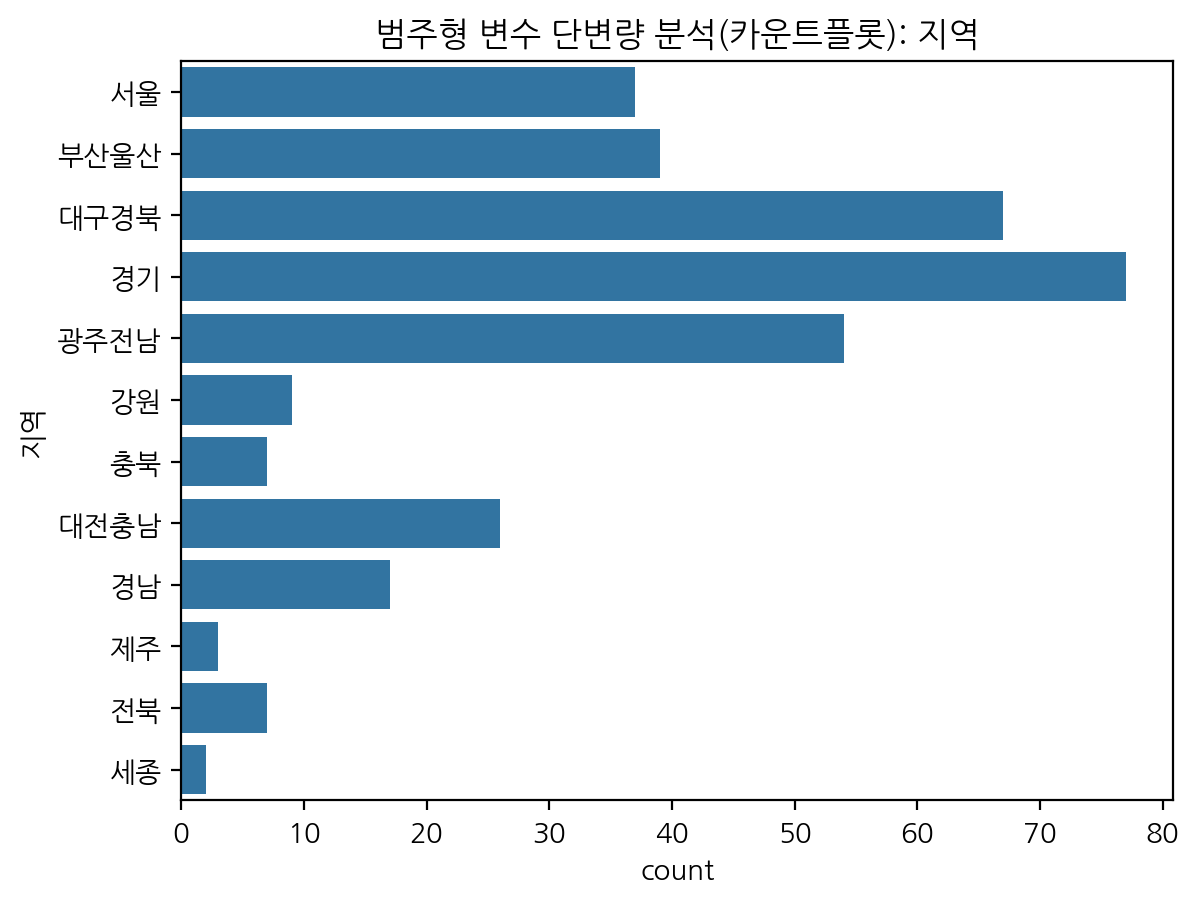

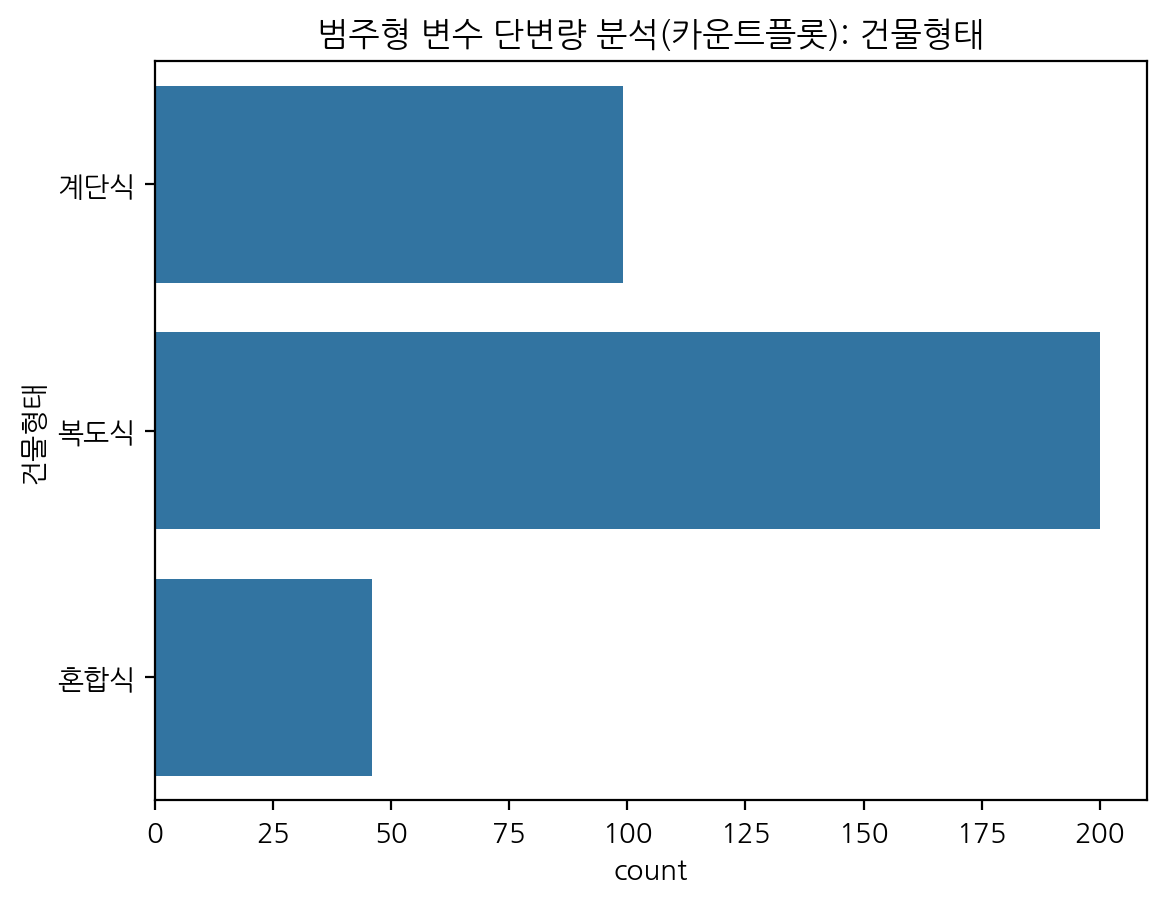

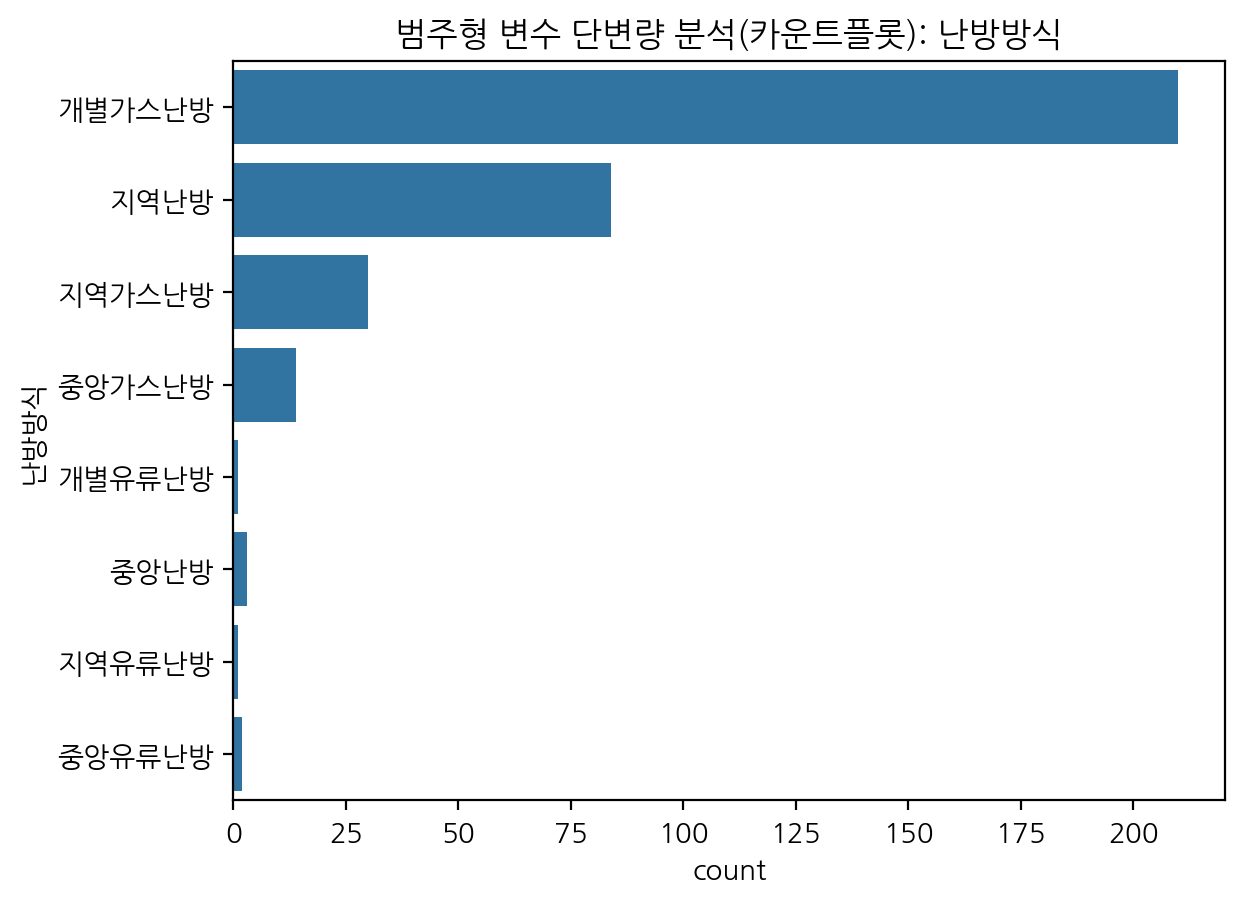

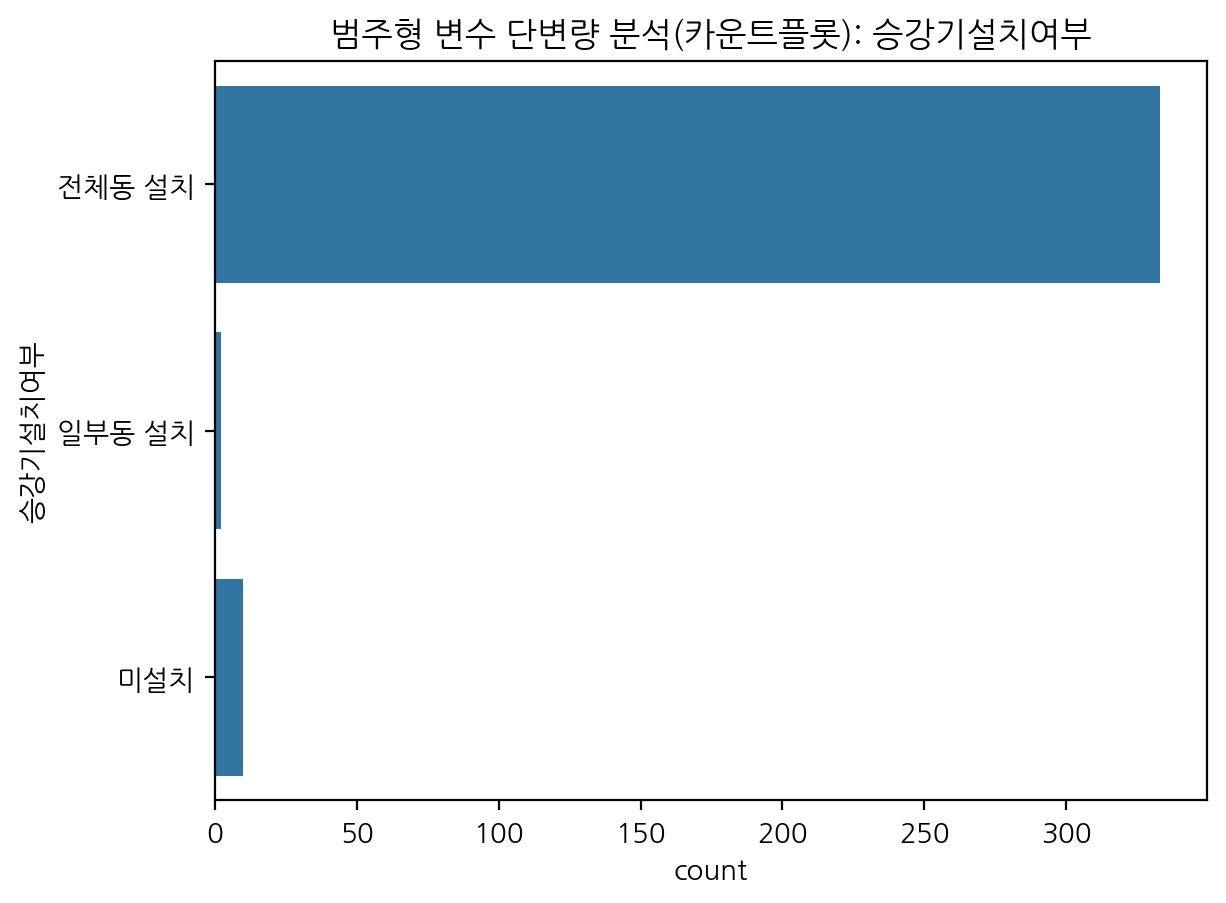

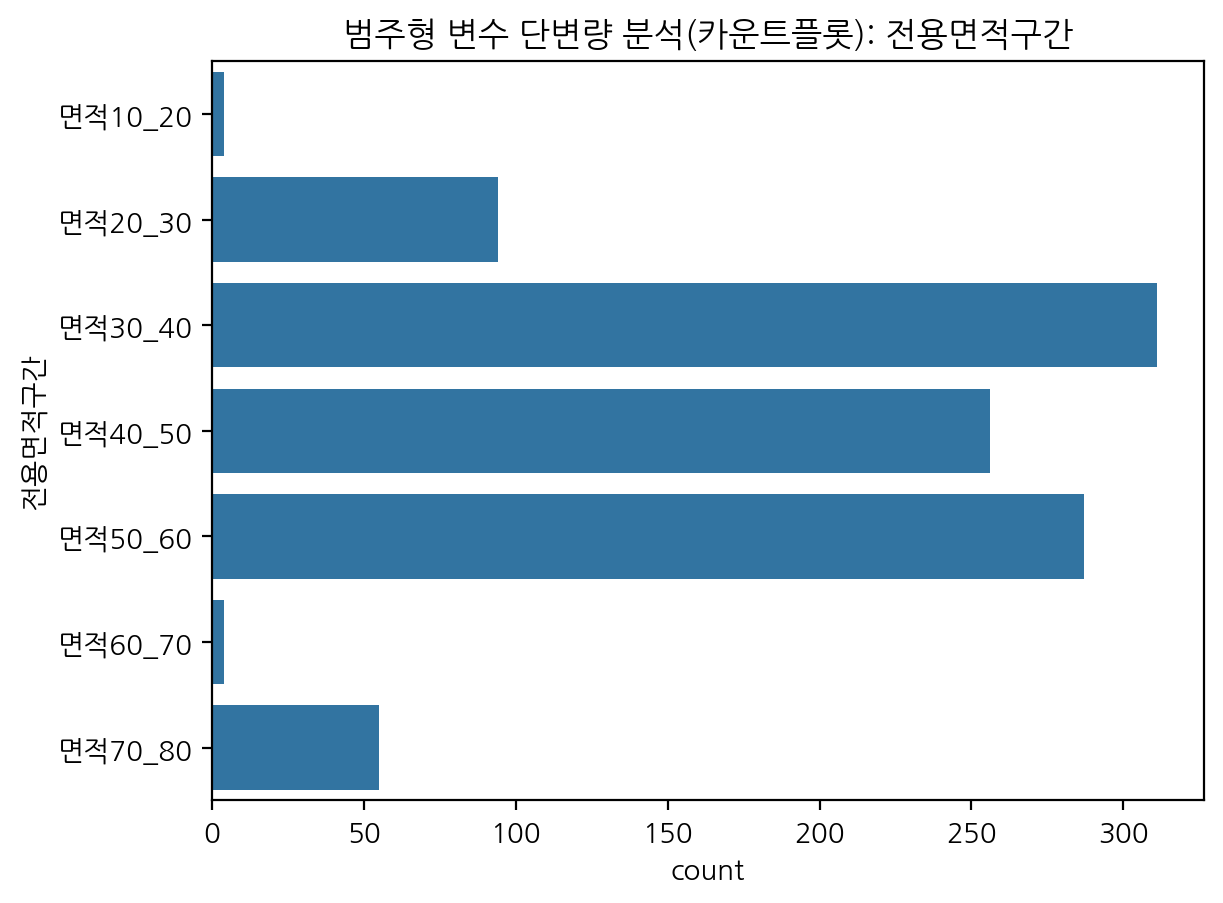

In [11]:
col_num = ['실차량수', '총세대수', '총면적', '준공연도', '임대료', '임대보증금']
col_cat = ['지역', '건물형태', '난방방식', '승강기설치여부']
os.makedirs('Figure', exist_ok=True)
fig_path = './그림/'
data = joblib.load(path+'base_data1.pkl')

def single_var_float(data, col):
    plt.figure()
    plt.hist(data[col], bins=10)
    plt.xlabel(f'{col}')
    plt.title(f'연속형 변수 단변량 분석(히스토그램): {col}')
    plt.savefig(fig_path + f'연속형 변수 단변량 분석(히스토그램)_{col}.png')
    plt.figure()
    sns.boxenplot(data[col])
    plt.title(f'연속형 변수 단변량 분석(박스플롯): {col}')
    plt.savefig(fig_path + f'연속형 변수 단변량 분석(박스플롯)_{col}.png')
    
# 함수 만들기
def single_var_cat(data, col):
    plt.figure()
    plt.title(f'범주형 변수 단변량 분석(카운트플롯): {col}')
    sns.countplot(data[col])
    plt.savefig(fig_path + f'범주형 변수 단변량 분석(카운트플롯)_{col}.png')
    
for col in tqdm(col_num):
    single_var_float(data, col)
    
for col in tqdm(col_cat):
    single_var_cat(data, col)

bins = [10, 20, 30, 40, 50, 60, 70, 80]
labels = [f'면적{bins[i]}_{bins[i+1]}' for i in range(0, len(bins)-1)]
labels_ = labels + ['단지코드']
temp = data[labels_]
temp = temp.melt(id_vars='단지코드', value_vars=labels, ignore_index=False)
#df_melt = df_pivot.melt(id_vars=labels, value_vars=labels)
#df_melt
temp = temp.loc[temp['value']>0]
temp_df = pd.DataFrame()
temp_list = []
for i in range(0, len(temp)):
    var = temp['variable'].iloc[i]
    val = temp['value'].iloc[i]
    for j in range(0, val):
        temp_list.append(var)
temp_df['전용면적구간'] = temp_list
single_var_cat(temp_df, '전용면적구간')

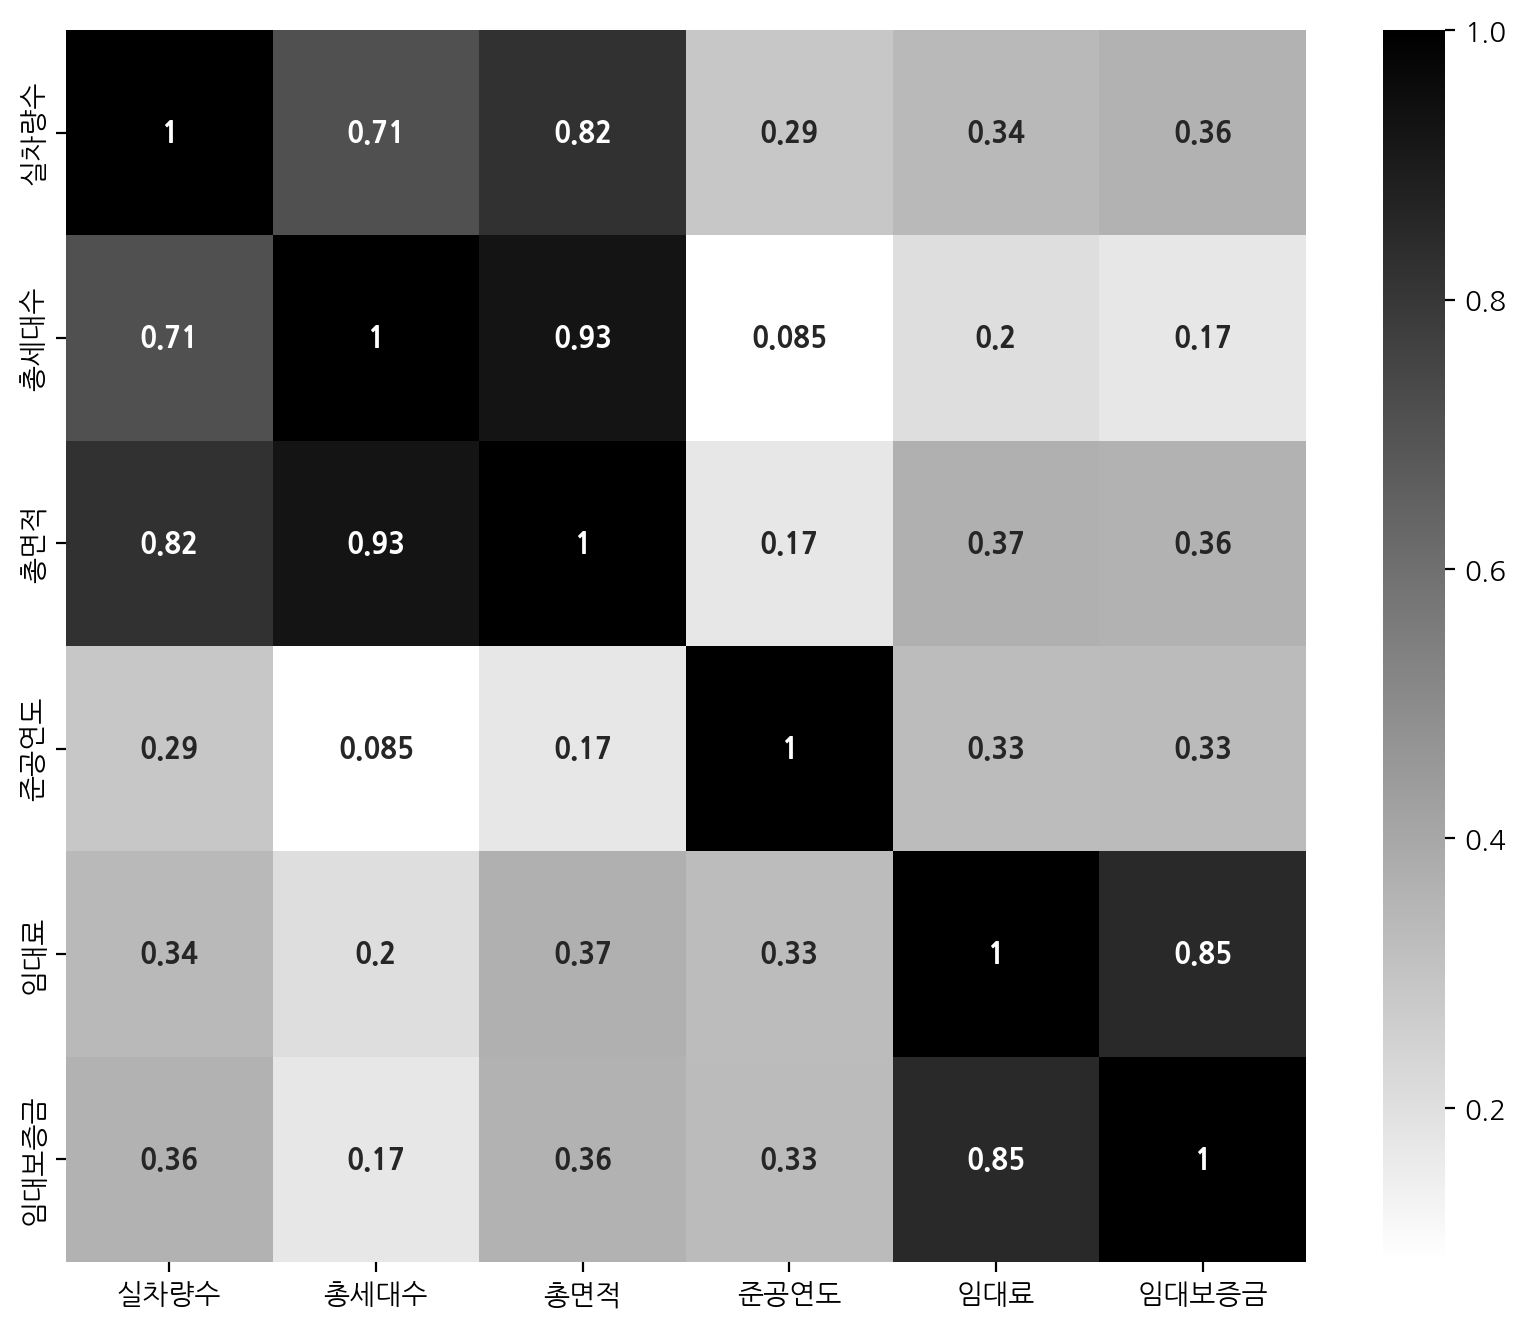

In [12]:
apart_num = data[col_num]
plt.figure(figsize=(10,8))
sns.heatmap(apart_num.corr(), annot=True, cmap='gray_r', annot_kws={'weight':'bold'})
plt.savefig(f'./그림/히트맵.png')

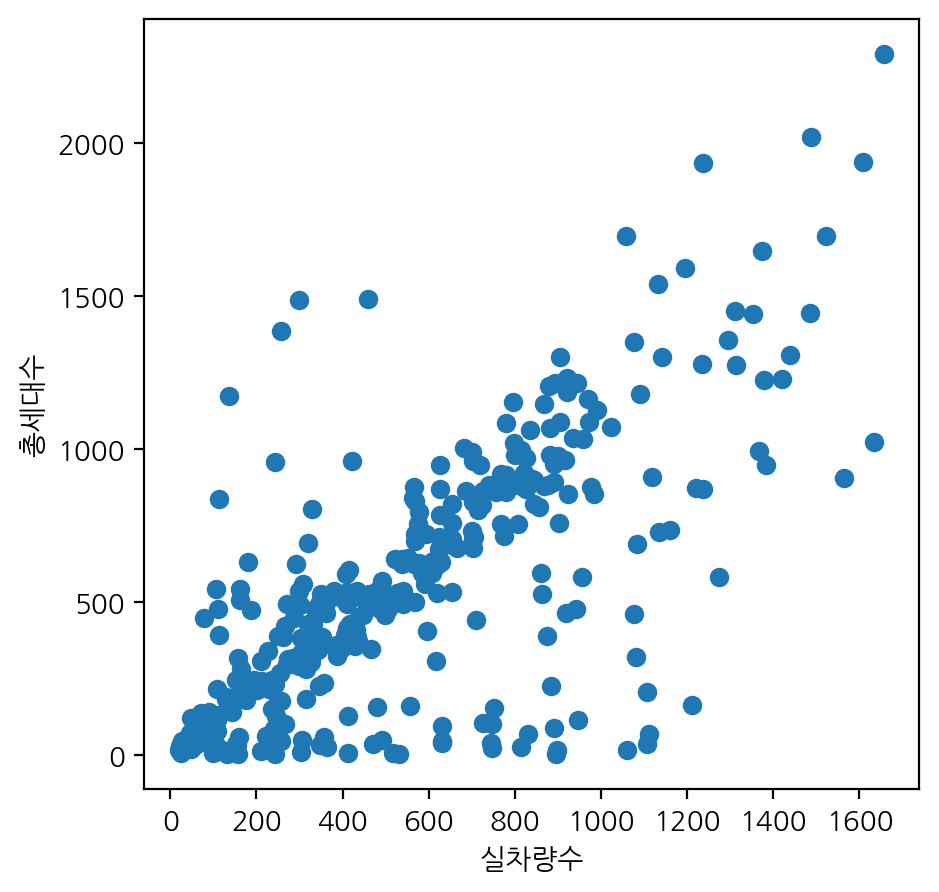

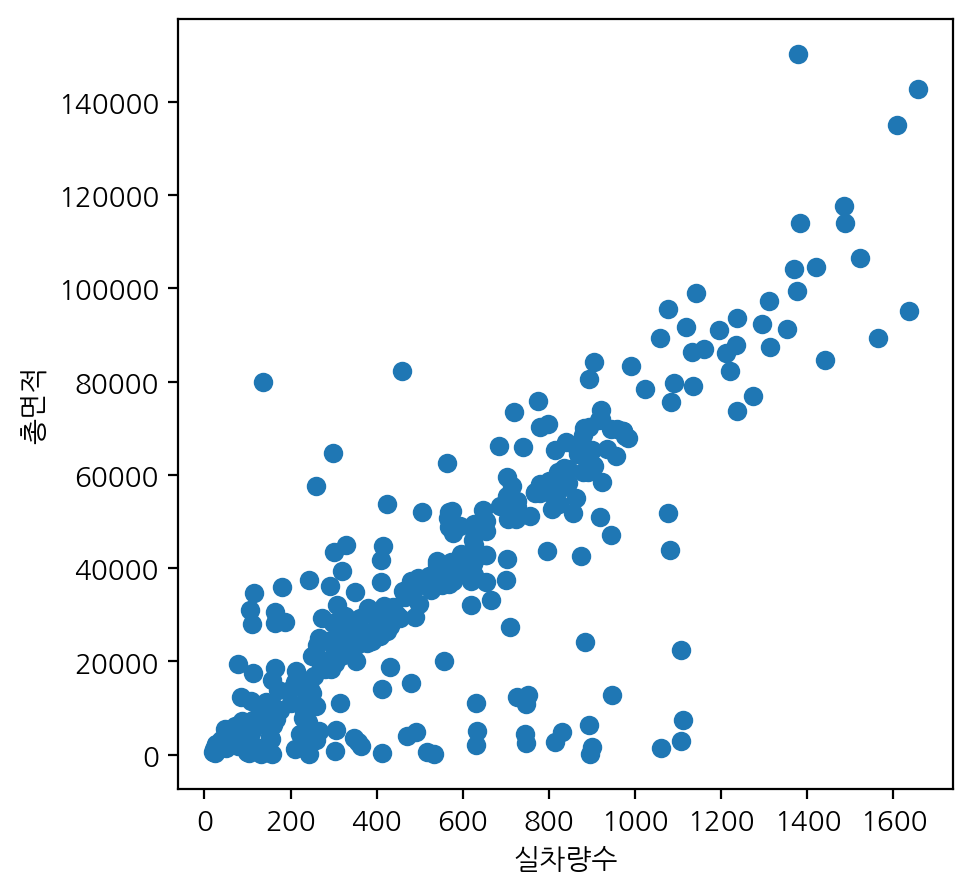

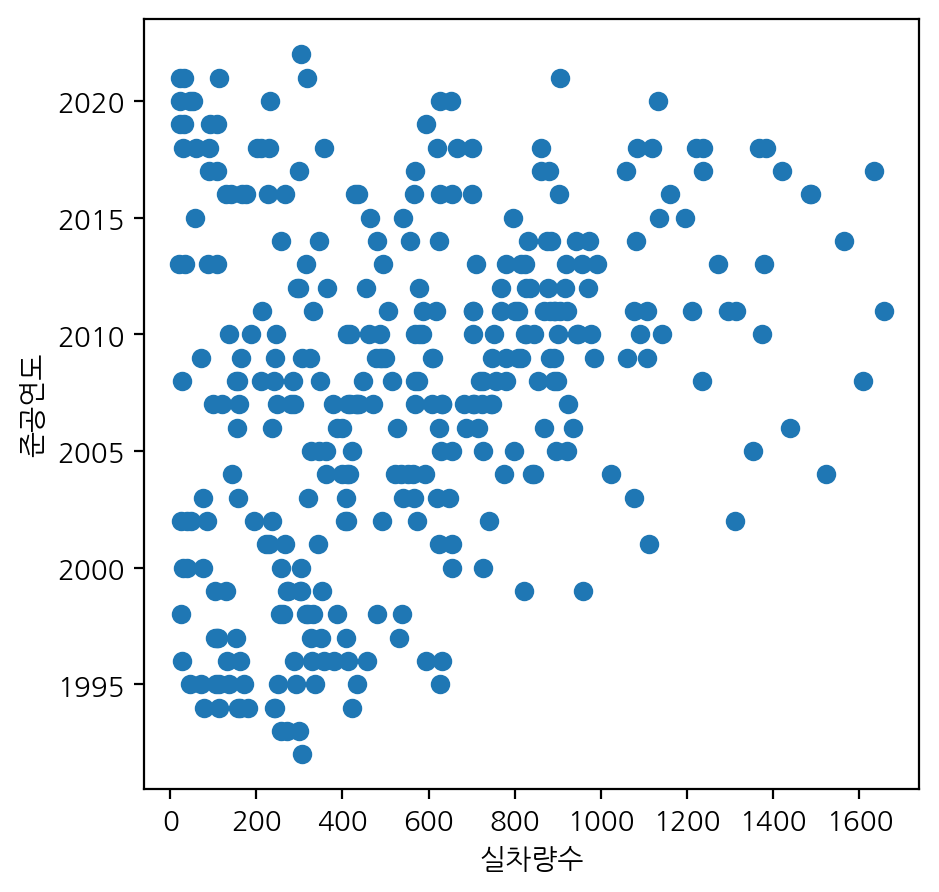

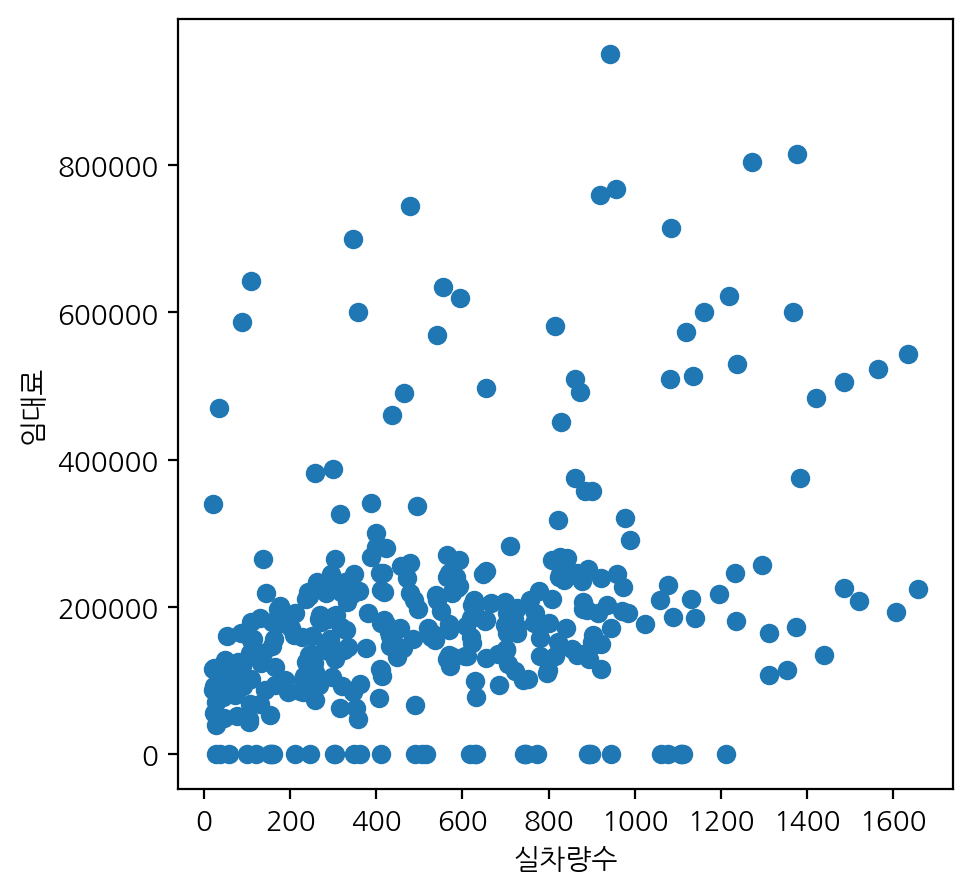

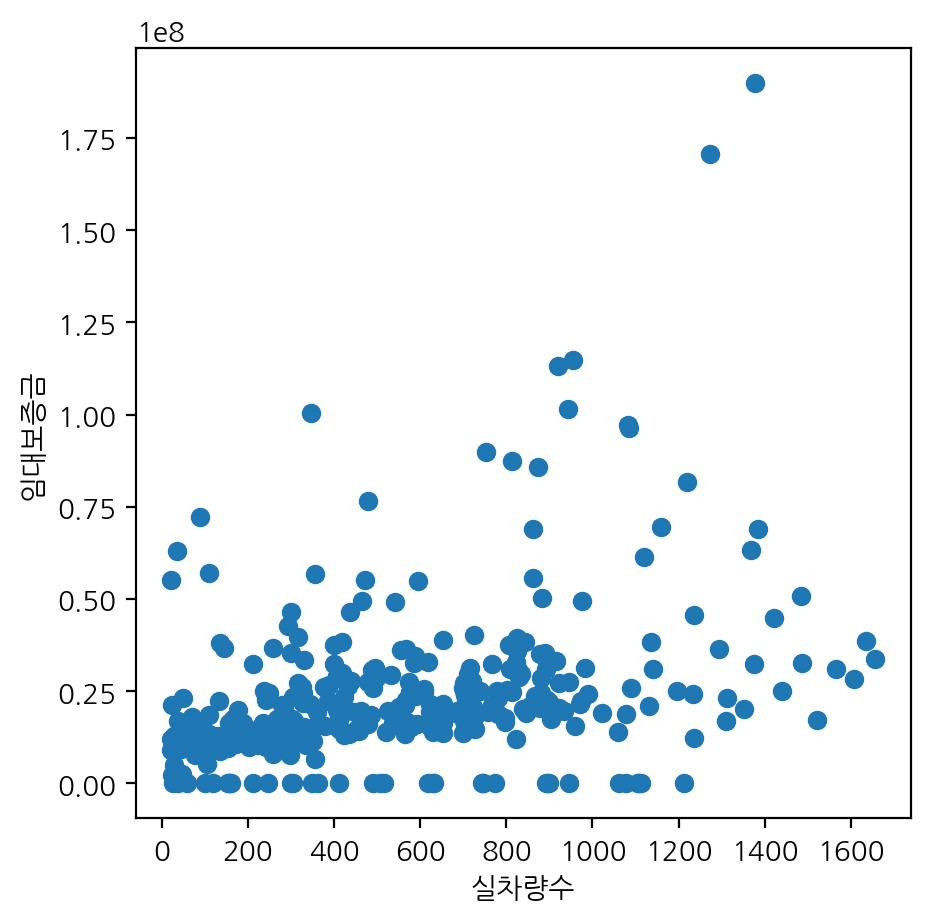

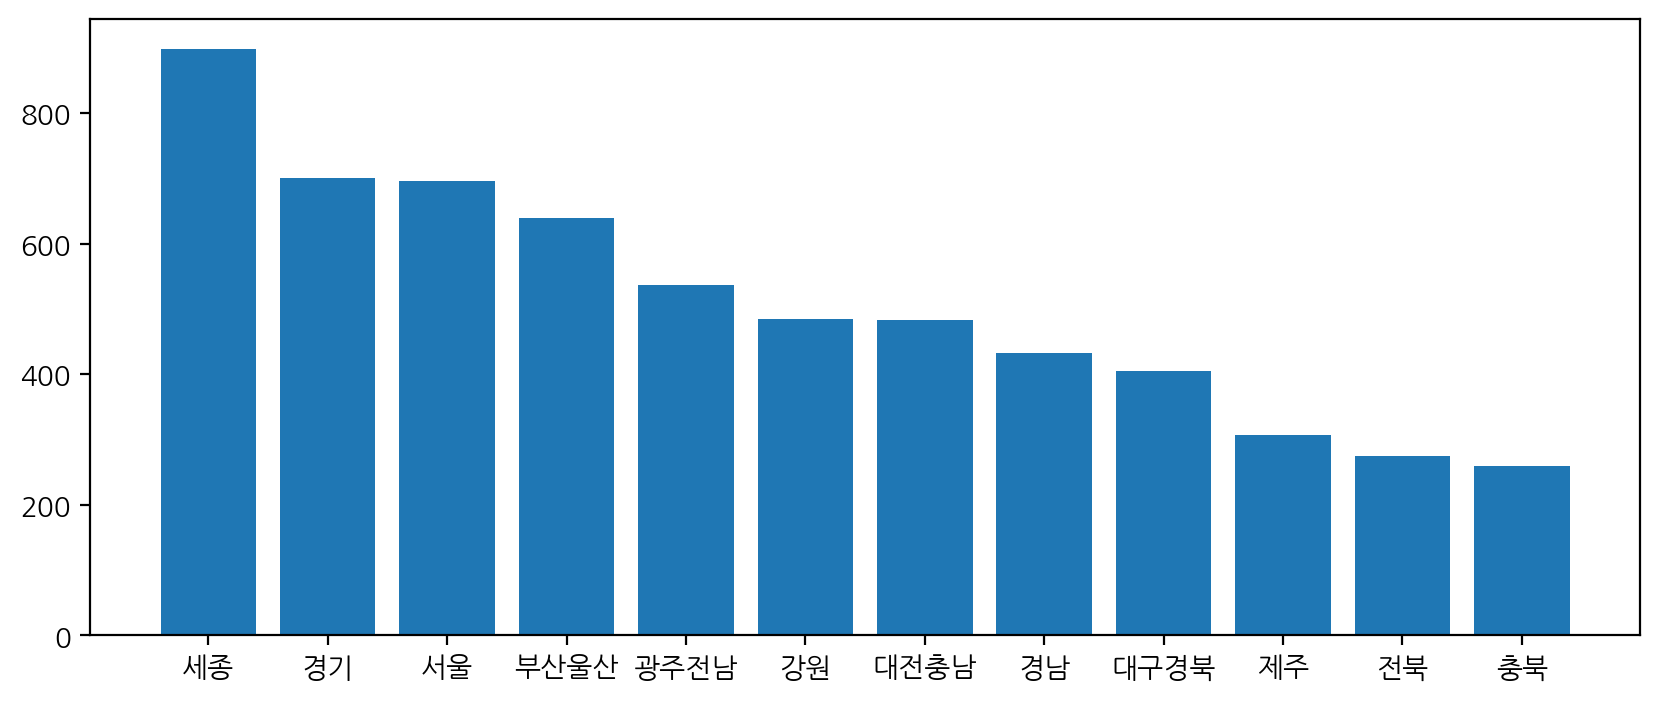

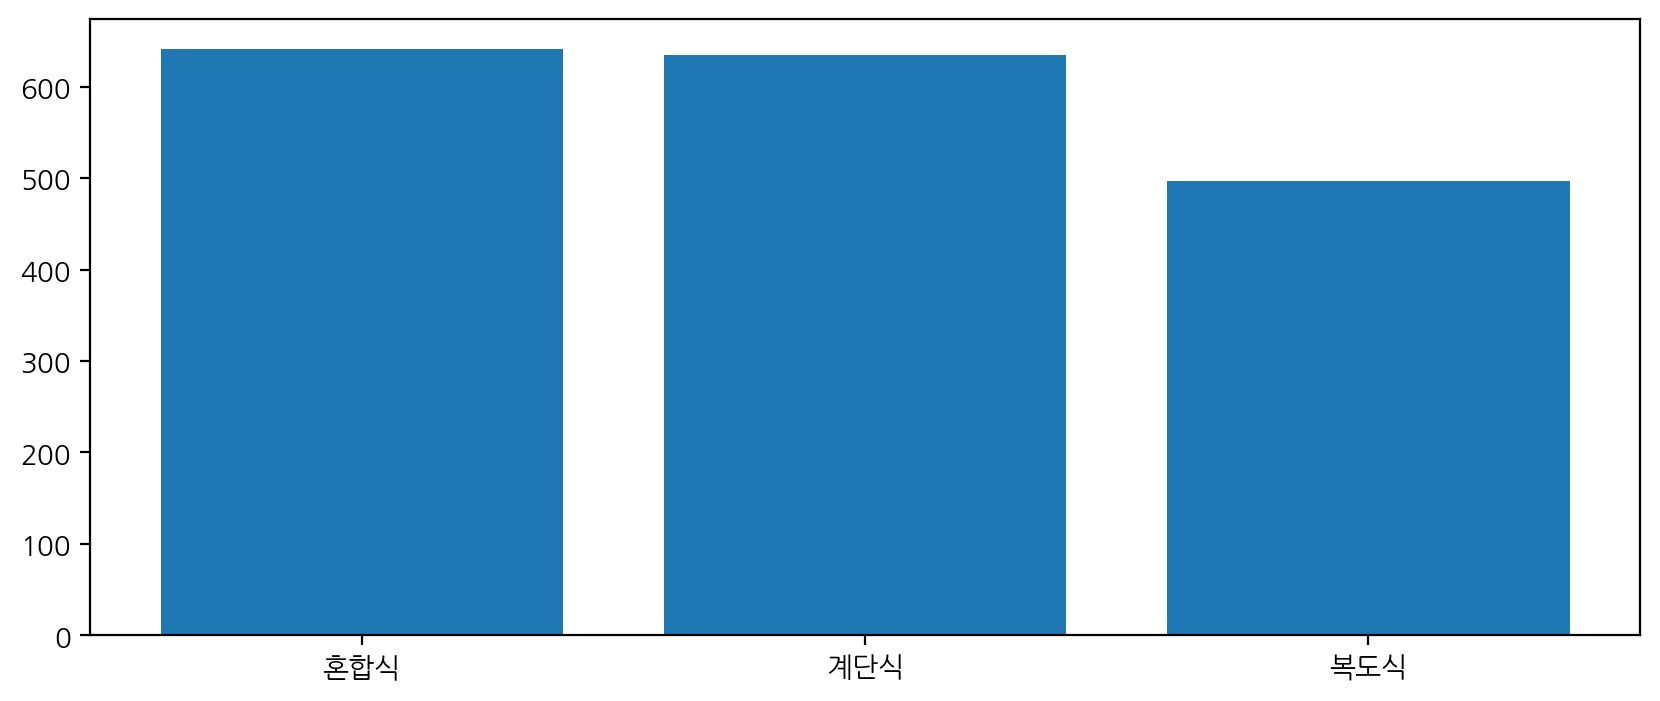

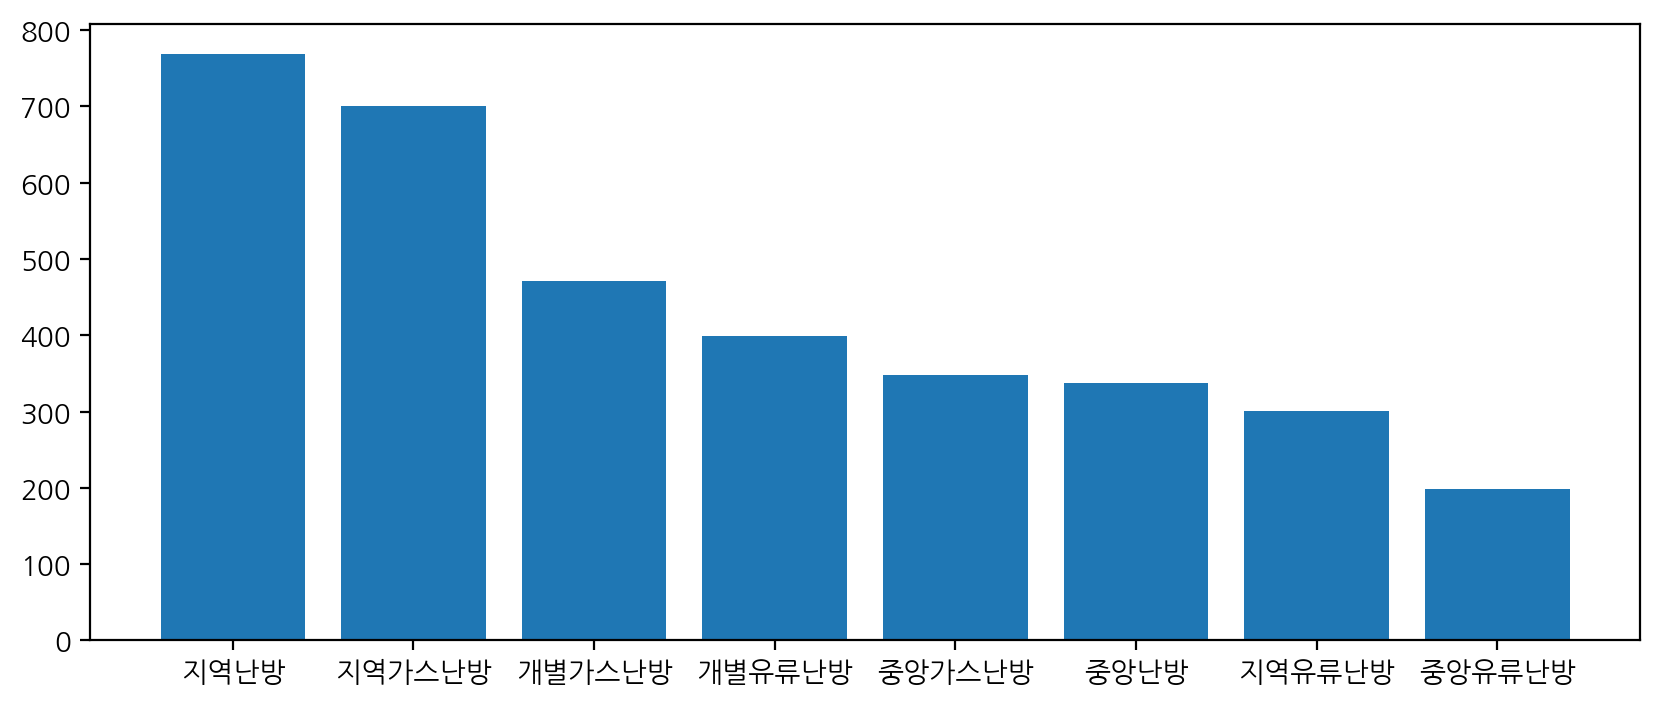

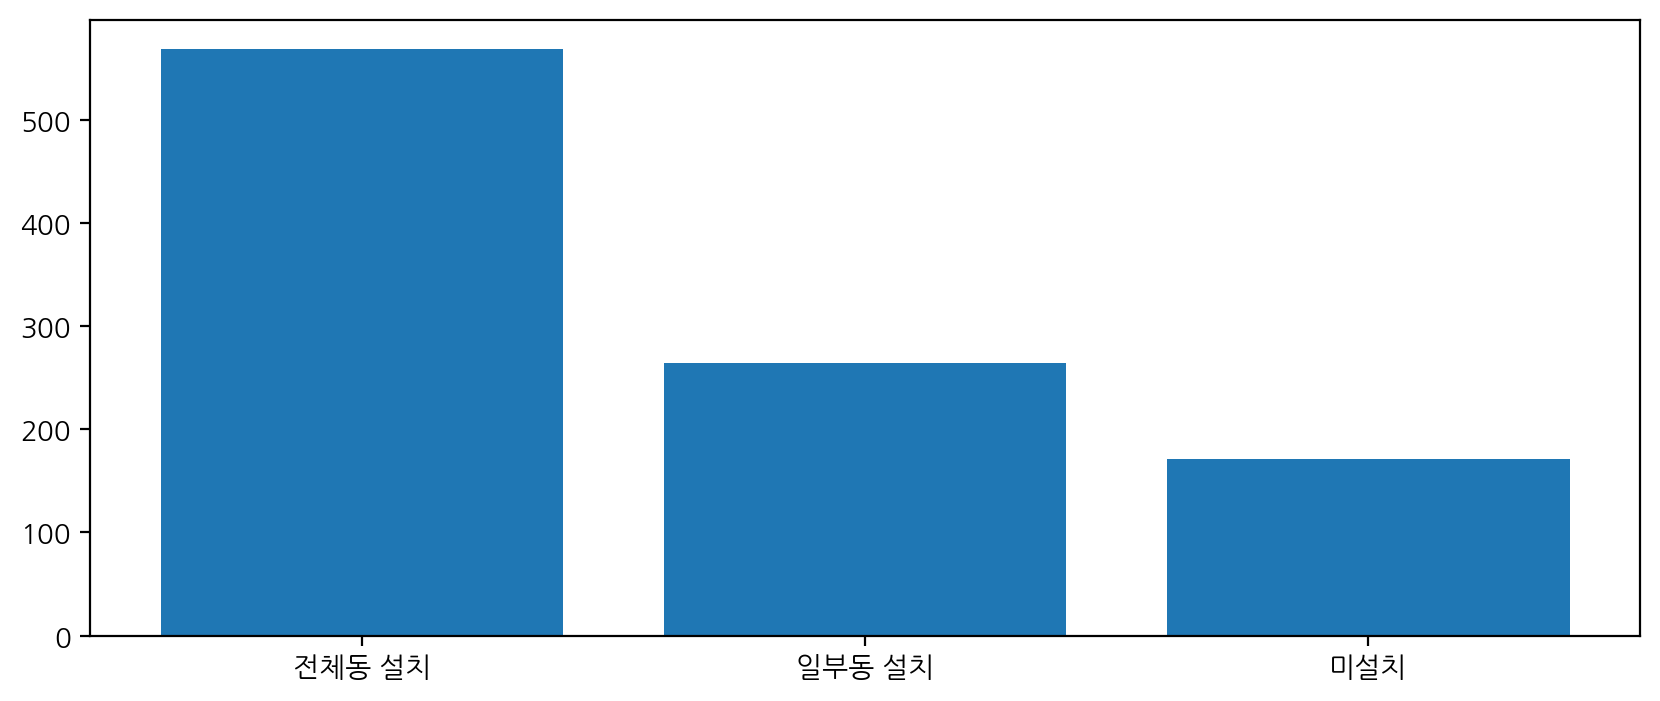

In [13]:
def num_analysis(target, col, data):
    plt.figure(figsize=(5,5))
    plt.scatter(data[target], data[col])
    plt.xlabel(target)
    plt.ylabel(col)
    plt.savefig(fig_path + f'다변량 분석 scatter_{col}.png')

def cate_analysis(data, col):
    data_ = data.groupby(col, as_index=False)['실차량수'].mean()
    data_ = data_.sort_values(by='실차량수', ascending=False)
    plt.figure(figsize=(10,4))
    plt.bar(height = data_['실차량수'], x = data_[col])
    plt.savefig(fig_path + f'다변량 분석 barchart_{col}.png')

col_num = ['총세대수', '총면적', '준공연도', '임대료', '임대보증금']
apart_cat = data[['실차량수', '지역', '준공연도', '건물형태', '난방방식', '승강기설치여부']]

for col in col_num:
    num_analysis('실차량수', col,apart_num)
for col in col_cat:
    cate_analysis(apart_cat, col)

### (6) 함수 생성

- 실젯값과 모델이 예측한 값을 시각화해 비교할 함수를 만듭니다.

In [237]:
# 실젯값, 예측값 비교 함수 만들기
def model_plot(model, y_test, y_pred):
    plt.figure(figsize=(10, 3))
    plt.plot(y_test.values, label='Actual', linewidth=0.7, marker='o', markersize=2)
    plt.plot(y_pred, label='Predicted', linewidth=0.7, marker='o', markersize=2)
    plt.title(f'{model}')
    plt.legend()
    plt.savefig(f'{model}.png')
    plt.show()

## 2. 모델링

- 모델링을 위한 결측치 처리, 데이터 분할, 스케일링, 가변수화 등을 수행합니다.
- 4개 이상의 알고리즘을 사용하여 모델을 만듭니다.
- 모델 이름은 서로 다르게 합니다. (예: model1, model2...)
- Linear Regression 이외의 알고리즘을 사용한 모델은 GridSearchCV() 함수로 성능 최적화를 수행합니다.
- 적절한 평가지표로 모델의 성능을 평가합니다.
- 실젯값과 예측값을 시각화해 비교합니다.
- 성능 비교를 통해 최선의 모델을 선정합니다.

### (1) 데이터 전처리

- 필요한 전처리를 수행합니다.

#### 1) x, y 분리

- Target를 지정하고, x와 y로 분리합니다.

In [174]:
data = joblib.load(path+'base_data2.pkl')
select_cols = ['총세대수', '승강기설치여부', '총면적', '난방방식', 
               '면적30_40', '면적40_50', '면적50_60']
target = '실차량수'
x = data.drop(columns=target)
y = data.loc[:, target]
x = x[select_cols].copy()
x.head()

,총세대수,승강기설치여부,총면적,난방방식,면적30_40,면적40_50,면적50_60
0,78,1,6023.7683,개별,0,0,2
1,35,1,1569.1668,개별,0,0,0
2,88,1,7180.1396,개별,0,0,4
3,477,1,47058.9273,지역,0,0,1
4,15,1,543.0268,개별,0,0,0


#### 2) 가변수화

- '건물형태', '난방방식' 변수에 대해 가변수화를 수행합니다.

In [21]:
dumm_cols = ['난방방식']
x = pd.get_dummies(x, columns=dumm_cols, drop_first=True, dtype=int)
x.head()

,총세대수,승강기설치여부,총면적,면적30_40,면적40_50,면적50_60,난방방식_중앙,난방방식_지역
0,78,1,6023.7683,0,0,2,0,0
1,35,1,1569.1668,0,0,0,0,0
2,88,1,7180.1396,0,0,4,0,0
3,477,1,47058.9273,0,0,1,0,1
4,15,1,543.0268,0,0,0,0,0


#### 3) 학습용, 평가용 분리

- 학습용, 평가용 데이터를 적절한 비율로 분리합니다.

In [23]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.3)

#### 4) 스케일링

- 필요한 경우 스케일링을 진행합니다.
- 예를 들어 KNN 알고리즘을 사용할 경우입니다.

In [25]:
scaler = MinMaxScaler()
x_train_s = scaler.fit_transform(x_train)
x_val_s = scaler.transform(x_val)

In [26]:
def set_result(model_name, r2, mae, rmse, r2_result, mae_result, rmse_result, model, model_dict):
    r2_result[model_name] = r2
    mae_result[model_name] = mae
    rmse_result[model_name] = rmse
    model_dict[model_name] = model
    return r2_result, mae_result, rmse_result, model_dict
r2_result = {}
mae_result = {}
rmse_result = {}
model_dict = {}

### (2) 모델 1: LinearRegression

In [28]:
model_name = 'LinearRegression'
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_val)
r2 = r2_score(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
rmse = root_mean_squared_error(y_val, y_pred)
r2_result, mae_result, rmse_result, model_dict = set_result(model_name, r2, mae, rmse, r2_result, mae_result, rmse_result, model, model_dict)
joblib.dump(model, f'{model_name}.pkl')
print(f'{model_name} complete!!')

LinearRegression complete!!


### (3) 모델 2: DecisionTree


In [30]:
model_name = 'DecisionTree'
param = {'max_depth': range(10, 21)}#,
         #'min_samples_split': [2, 5, 10, 20, 50],
         #'min_samples_leaf': [1, 2, 5, 10, 20]}
model_ = DecisionTreeRegressor(max_depth=5)
model = GridSearchCV(model_, param, cv=5, scoring='r2')
model.fit(x_train, y_train)
y_pred = model.predict(x_val)
r2 = r2_score(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
rmse = root_mean_squared_error(y_val, y_pred)
r2_result, mae_result, rmse_result, model_dict = set_result(model_name, r2, mae, rmse, r2_result, mae_result, rmse_result, model, model_dict)
joblib.dump(model, f'{model_name}.pkl')
print(f'{model_name} complete!!')

DecisionTree complete!!


### (4) 모델 3: RandomForest

In [32]:
model_name = 'RandomForest'
param = {'max_depth': range(10, 21)}#,
        #'min_samples_split':[2,5,10,20,50],
        #'min_samples_leaf': [1, 2, 5, 10, 20],
        #'n_estimators': [100, 200, 300]}
model_ = RandomForestRegressor()
model = GridSearchCV(model_, param, cv=5, scoring='r2')
model.fit(x_train, y_train)
y_pred = model.predict(x_val)
r2 = r2_score(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
rmse = root_mean_squared_error(y_val, y_pred)
r2_result, mae_result, rmse_result, model_dict = set_result(model_name, r2, mae, rmse, r2_result, mae_result, rmse_result, model, model_dict)
joblib.dump(model, f'{model_name}.pkl')
print(f'{model_name} complete!!')

RandomForest complete!!


### (5) 모델 4: XGBoost

In [34]:
model_name = 'XGBoost'
model_ = XGBRegressor()
param = {'max_depth': range(1, 21)}#,
        #'learning_rate': [0.01, 0.05, 0.1, 0.2],
        #}
model = GridSearchCV(model_, param_grid=param, cv=5, scoring='r2')
model.fit(x_train, y_train)
y_pred = model.predict(x_val)
r2 = r2_score(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
rmse = root_mean_squared_error(y_val, y_pred)
r2_result, mae_result, rmse_result, model_dict = set_result(model_name, r2, mae, rmse, r2_result, mae_result, rmse_result, model, model_dict)
joblib.dump(model, f'{model_name}.pkl')
print(f'{model_name} complete!!')

XGBoost complete!!


### (6) 성능 비교

- 각 모델의 성능을 비교합니다.

In [54]:
result_df = pd.DataFrame()
result_df['r2'] = r2_result
result_df['MAE'] = mae_result
result_df['RMSE'] = rmse_result
result_df.sort_values(by = 'r2', ascending=False, inplace=True)
result_df

,r2,MAE,RMSE
XGBoost,0.808019,125.732713,161.467761
LinearRegression,0.761167,132.266465,180.096113
RandomForest,0.740315,128.412786,187.793347
DecisionTree,0.523178,157.363075,254.468980


In [265]:
model_list = ['XGBoost', 'RandomForest', 'DecisionTree']
for model_name in model_list: 
    model = model_dict[model_name]
    y_pred = model.predict(x_val)
    print(model_name)
    print(model.best_params_)
    print(r2_score(y_val, y_pred))

XGBoost
{'max_depth': 1}
0.8080191411316667
RandomForest
{'max_depth': 10}
0.7403151042514544
DecisionTree
{'max_depth': 12}
0.5231783333857154


In [233]:
list(result_df.index)

['XGBoost', 'LinearRegression', 'RandomForest', 'DecisionTree']

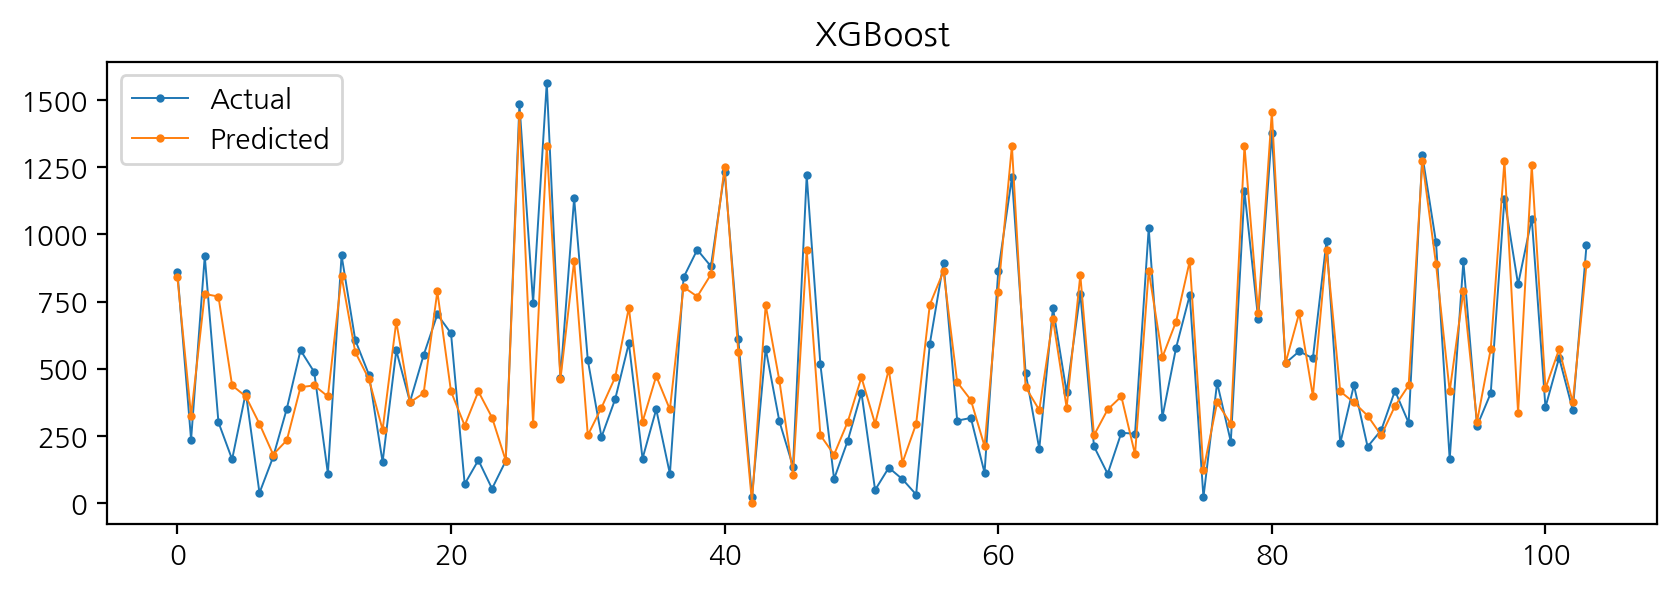

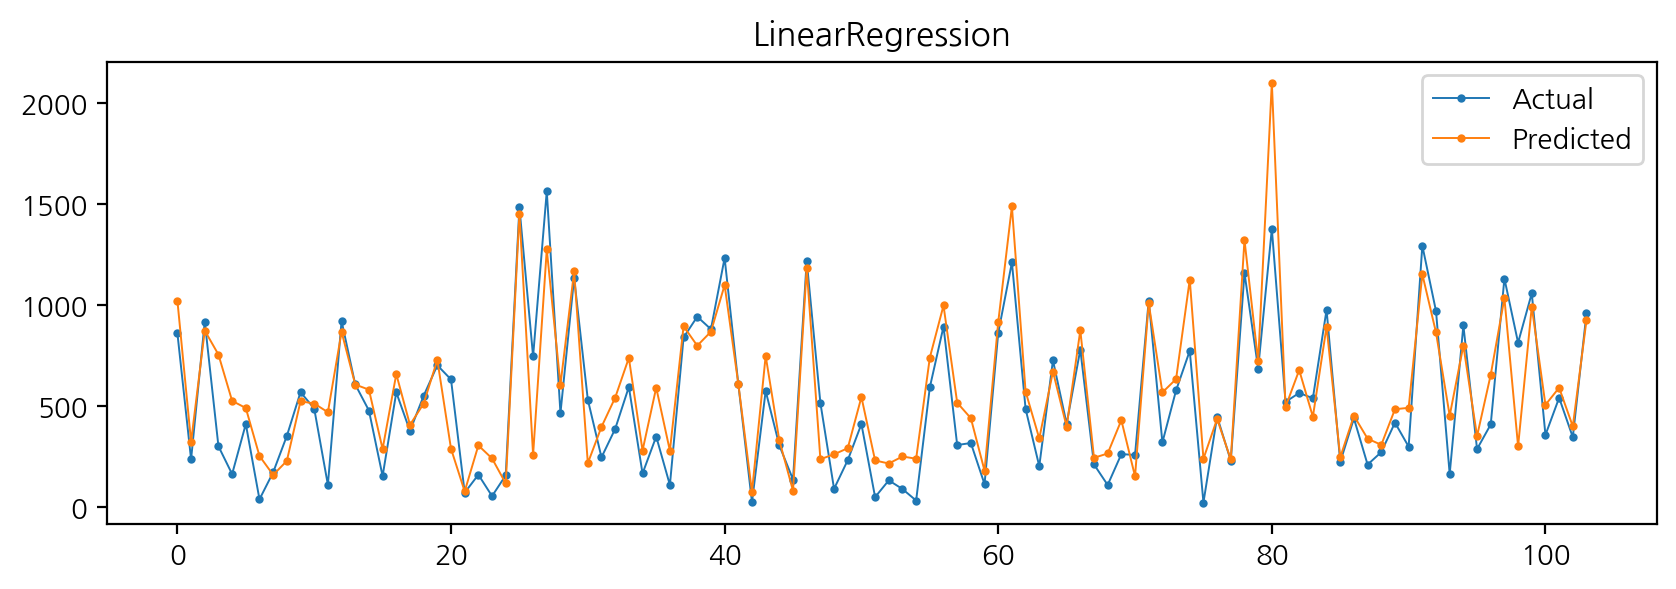

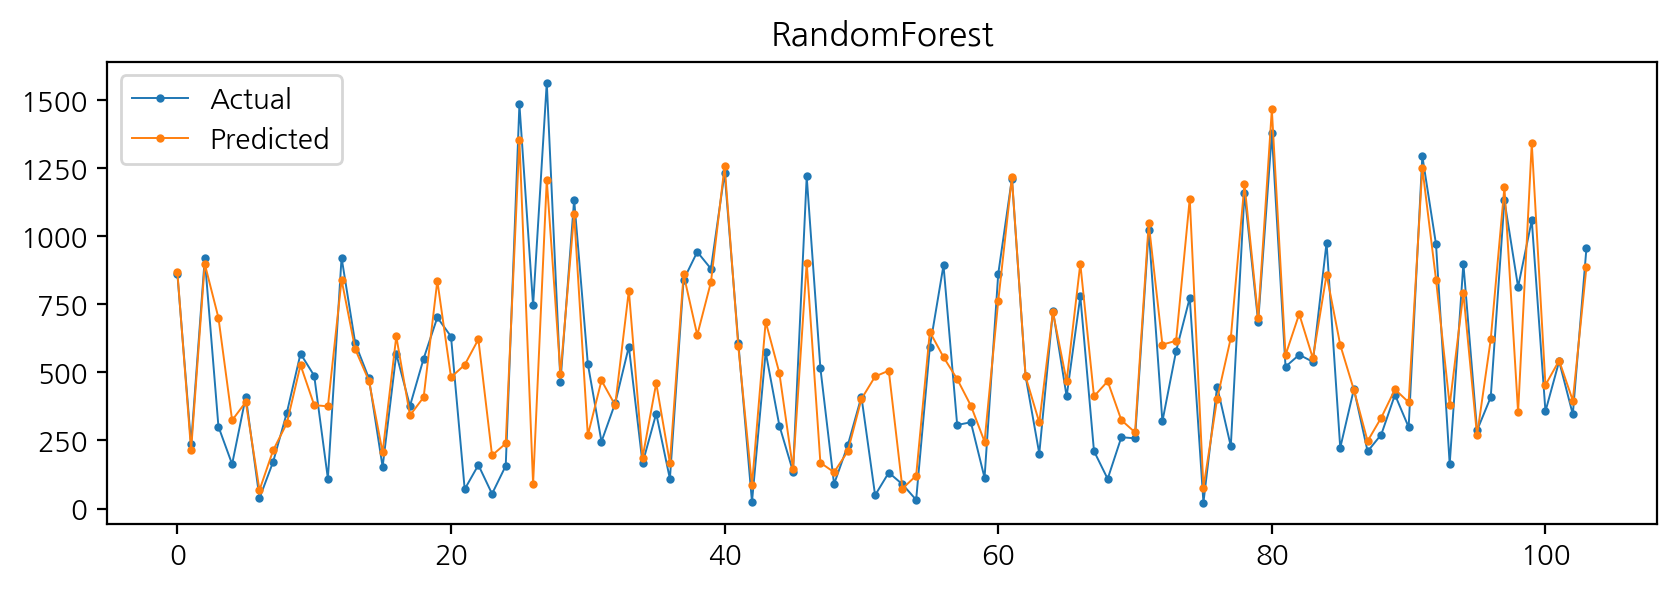

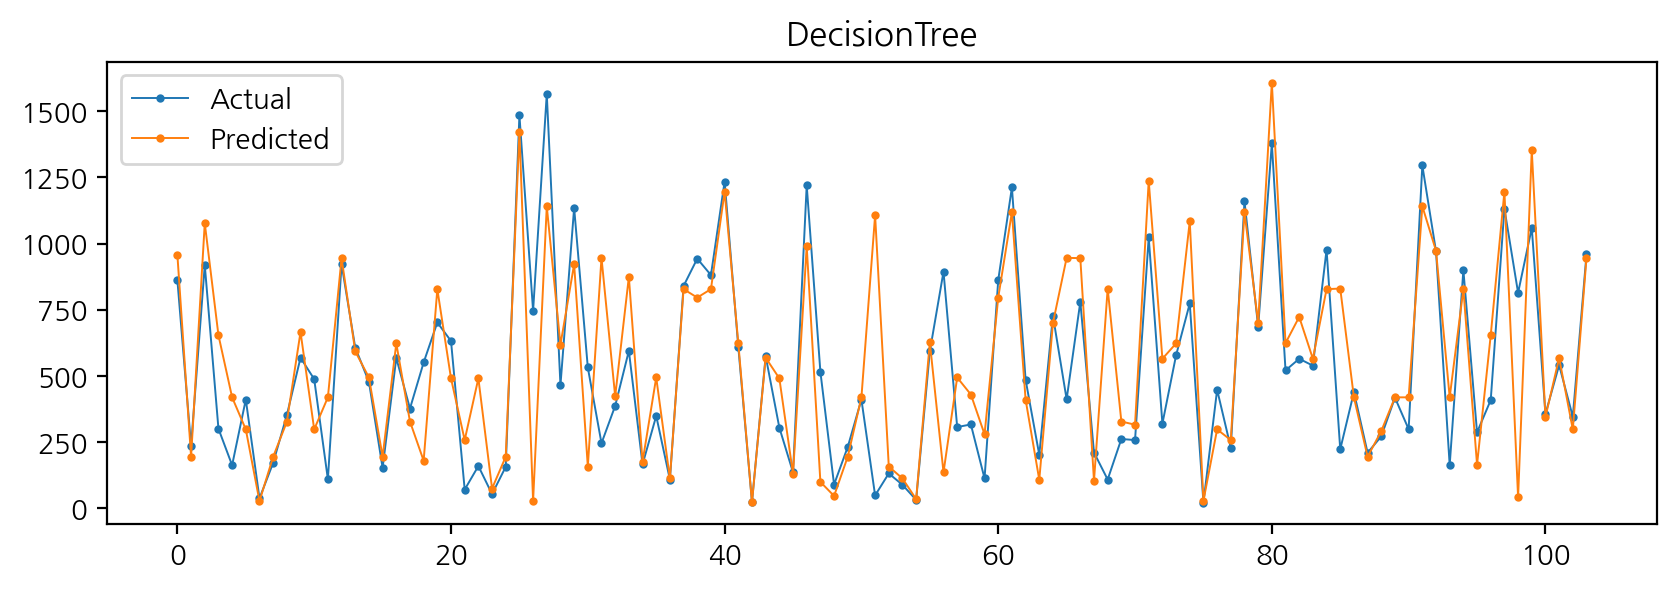

In [247]:
model_list = list(result_df.index)
for model_name in model_list:
    model = joblib.load(f'{model_name}.pkl')
    y_pred = model.predict(x_val)
    model_plot(model_name, y_val, y_pred)

## 3. 파이프라인 구축

- 새로운 데이터를 불러오고, 이 데이터를 처리할 파이프라인 함수를 만듭니다.

### (1) 데이터 파이프라인 구축

- 데이터 파이프라인 함수를 만듭니다.
- 학습 데이터에 대해 진행했던 모든 전처리 과정을 평가 데이터에도 일괄 진행해야 합니다.
    - 입력: new_data
    - 출력: 전처리가 완료된 예측 직전 데이터프레임
- 새로운 데이터에는 '실차량수' 변수가 없음을 유의합니다.
- 참고: 다음 내용들이 처리되어야 합니다.
    - 결측치 처리
    - 변수 추가
    - 불필요한 변수 제거
    - 단지 데이터, 상세 데이터 분리
    - 단지코드별 총면적 합 집계
    - 전용면적 구간별 집계 (피벗 형태)
    - 임대보증금, 임대료 평균 집계
    - 집계 결과 병합
    - 난방방식: 개별, 지역, 중앙 세 가지로 묶기
    - 승강기설치여부: 0, 1 값으로 변경
    - 단지모드, 지역 변수 제거
    - 가변수화

In [206]:
# 파이프라인 만들기
def data_pipeline(data):
        # 범주형 변수 -> 최빈값으로 결측치를 보간하는 함수
    def fillna_col(columns, data):
        tmp = data[columns].value_counts(dropna=True)
        max_v = max(data[columns].value_counts(dropna=True))
        max_c = tmp.loc[tmp==max_v].index[0]
        data[columns] = data[columns].fillna(max_c)
        return data
    # 숫자형 변수 -> 선형보간하는 함수
    def fillna_val(columns, data):
        data[columns] = data[columns].interpolate(method='linear')
        return data
    
    def fillna_total(data):
        tmp_n = data.isna().sum()
        nan_list = list(tmp_n[tmp_n>0].index)
        for columns in nan_list:
            if data[columns].dtype == 'O':
                fillna_col(columns, data)
            else:
                fillna_val(columns, data)
        return data
    data = fillna_total(data)
    def add_var(data):
        # 준공연도
        data['준공일자'] = data['준공일자'].astype('str')
        data['준공연도'] = data['준공일자'].str[:4]
        data['준공연도'] = data['준공연도'].astype(np.dtype("int64"))
    
        # 총 면적
        data['총면적'] = (data['전용면적'] + data['공용면적']) * data['전용면적별세대수'] 
        return data
    apart = add_var(data)
    apart
    def remove_var(data, col):
        data.drop(col, axis=1, inplace=True)
        return data
    remove_col = ['단지명', '단지내주차면수', '준공일자']
    apart = remove_var(apart, remove_col)
    
    def data01_process(data):
        data01 = data[['단지코드', '총세대수', '지역', '준공연도', '건물형태', '난방방식', '승강기설치여부']]
        len_1 = len(data01)
        data01 = data01.drop_duplicates()
        data01.reset_index()
        len_2 = len(data01)
        print(f'number of before data01 processing: {len_1}')
        print(f'number of after data01 processing: {len_2}')
        return data01
    data01 = data01_process(apart)

    def data02_process1(data, col1, col2):
        data02 = data[['단지코드', '총면적', '전용면적별세대수', '전용면적', '공용면적', '임대보증금', '임대료']]
        df_area = data02.groupby(col1, as_index=False)[col2].sum()
        return df_area
    df_area = data02_process1(apart, '단지코드', '총면적')

    def data02_process2(data, col1, col2):
        data02 = data[['단지코드', '총면적', '전용면적별세대수', '전용면적', '공용면적', '임대보증금', '임대료']]
        bins = [10, 30, 40, 50, 60, 70, 80, 200]
        labels = [f'면적{bins[i]}_{bins[i+1]}' for i in range(0, len(bins)-1)]
        data02['전용면적구간'] = pd.cut(data02[col2], bins = bins, labels = labels, right=False)
        tmp = data02.groupby([col1, '전용면적구간'], as_index = False)['전용면적구간'].value_counts()
        df_pivot = tmp.pivot(index=col1, columns='전용면적구간')
        df_pivot[labels] = df_pivot['count'][labels]
        df_pivot = df_pivot.drop('count', axis=1)
        df_pivot[col1] = list(df_pivot.index)
        df_pivot.reset_index(drop=True, inplace=True)
        temp_ = pd.DataFrame()
        temp_['단지코드'] = df_pivot['단지코드']
        temp_[labels] = df_pivot[labels]
        df_pivot = temp_
        return df_pivot
    data02 = data[['단지코드', '총면적', '전용면적별세대수', '전용면적', '공용면적', '임대보증금', '임대료']]
    df_pivot = data02_process2(apart, '단지코드', '전용면적')
    data02.groupby(['단지코드', '임대보증금'], as_index = False)['임대보증금'].mean()
    def data02_process3(data):
        data02 = data[['단지코드', '총면적', '전용면적별세대수', '전용면적', '공용면적', '임대보증금', '임대료']]
        df_rent = data02.groupby('단지코드', as_index = False)['임대보증금'].mean()
        df_rent['임대료'] = data02.groupby('단지코드', as_index = False)['임대료'].mean()['임대료']
        return df_rent
    data02 = data[['단지코드', '총면적', '전용면적별세대수', '전용면적', '공용면적', '임대보증금', '임대료']]
    df_rent = data02_process3(apart)
    temp1 = pd.merge(df_area, df_rent, on='단지코드', how='left')
    temp2 = pd.merge(temp1, df_pivot, how='left', on='단지코드')
    base_data = pd.merge(data01, temp2, how='left', on='단지코드')

    base_data['난방방식'] = base_data['난방방식'].replace({
        '개별가스난방': '개별',
        '개별유류난방': '개별',
        '지역난방': '지역',
        '지역가스난방': '지역',
        '지역유류난방': '지역',
        '중앙가스난방': '중앙',
        '중앙난방': '중앙',
        '중앙유류난방': '중앙'
    })

    base_data['승강기설치여부'] = base_data['승강기설치여부'].replace({
        '전체동 설치': int(1),
        '일부동 설치': int(0),
        '미설치': int(0)
    })

    base_data = base_data.drop(columns=['단지코드', '지역'])
    return base_data

### (2) New Data 불러오기

- test.xlsx 파일을 읽어와 new_data 데이터프레임으로 선언합니다.
- 해당 데이터는 '실차량수' 변수가 없는 것 외에는, 최초 데이터와 동일한 구조입니다.
- 이 데이터를 대상으로 전처리와 예측을 수행합니다.

In [209]:
# 파일 읽어오기
new_data = pd.read_excel(path+'test.xlsx')

# 확인
new_data.head()

,단지코드,단지명,총세대수,전용면적별세대수,지역,준공일자,건물형태,난방방식,승강기설치여부,단지내주차면수,전용면적,공용면적,임대보증금,임대료
0,C0005,서울석촌 도시형주택(공임10년),20,6,서울,20121115,복도식,개별가스난방,전체동 설치,9,17.53,11.7251,50449000,263710
1,C0005,서울석촌 도시형주택(공임10년),20,10,서울,20121115,복도식,개별가스난방,전체동 설치,9,24.71,16.5275,52743000,321040
2,C0005,서울석촌 도시형주택(공임10년),20,4,서울,20121115,복도식,개별가스난방,전체동 설치,9,26.72,17.8720,53890000,332510
3,C0017,대구혁신센텀힐즈,822,228,대구경북,20180221,계단식,지역난방,NaN,824,51.87,20.9266,29298000,411200
4,C0017,대구혁신센텀힐즈,822,56,대구경북,20180221,계단식,지역난방,NaN,824,59.85,24.1461,38550000,462600


### (3) 예측하기

- new_data를 파이프라인을 사용해 전처리한 후 가장 성능이 좋았던 모델로 예측한 결과를 확인합니다.

In [212]:
# 데이터 전처리
input_data = new_data.copy()
data = data_pipeline(input_data)

# 확인
data.head()

number of before data01 processing: 104
number of after data01 processing: 30


,총세대수,준공연도,건물형태,난방방식,승강기설치여부,총면적,임대보증금,임대료,면적10_30,면적30_40,면적40_50,면적50_60,면적60_70,면적70_80,면적80_200
0,20,2012,복도식,개별,1,766.2736,5.236067e+07,305753.333333,3,0,0,0,0,0,0
1,822,2018,계단식,지역,1,31396.0944,3.546600e+07,445466.666667,0,0,0,3,0,0,0
2,112,2014,계단식,지역,1,12450.4308,9.869750e+07,744450.000000,0,0,0,0,0,1,1
3,122,2011,계단식,지역,1,13081.4772,0.000000e+00,0.000000,0,0,0,0,0,2,4
4,262,2011,계단식,지역,1,28141.7516,0.000000e+00,0.000000,0,0,0,0,0,1,3


In [214]:
# 데이터 처리
data = data[select_cols]
x = pd.get_dummies(data, columns=dumm_cols, drop_first=True, dtype=int)
x.head()

,총세대수,승강기설치여부,총면적,면적30_40,면적40_50,면적50_60,난방방식_중앙,난방방식_지역
0,20,1,766.2736,0,0,0,0,0
1,822,1,31396.0944,0,0,3,0,1
2,112,1,12450.4308,0,0,0,0,1
3,122,1,13081.4772,0,0,0,0,1
4,262,1,28141.7516,0,0,0,0,1


In [216]:
# 예측 하기
best_model = 'XGBoost'
model = joblib.load(f'{best_model}.pkl')
predicted = model.predict(x)
print(predicted)

[ 123.45132  432.33307  544.4499   396.54288  468.084    295.05276
  415.6183   396.54288  511.67734  472.5801   320.389    268.97363
 1378.9904   697.63446  675.38434  734.9302   697.63446  265.05557
  906.36993  884.9669   325.4895   828.7716   851.0217   828.7716
  862.7167   396.54288  348.48297 1163.6876   286.79788  732.93677]


- 아파트 기본 정보에 예측한 차량수를 붙여 마무리합니다.

In [219]:
new_data

,단지코드,단지명,총세대수,전용면적별세대수,지역,준공일자,건물형태,난방방식,승강기설치여부,단지내주차면수,전용면적,공용면적,임대보증금,임대료
0,C0005,서울석촌 도시형주택(공임10년),20,6,서울,20121115,복도식,개별가스난방,전체동 설치,9,17.53,11.7251,50449000,263710
1,C0005,서울석촌 도시형주택(공임10년),20,10,서울,20121115,복도식,개별가스난방,전체동 설치,9,24.71,16.5275,52743000,321040
2,C0005,서울석촌 도시형주택(공임10년),20,4,서울,20121115,복도식,개별가스난방,전체동 설치,9,26.72,17.8720,53890000,332510
3,C0017,대구혁신센텀힐즈,822,228,대구경북,20180221,계단식,지역난방,NaN,824,51.87,20.9266,29298000,411200
4,C0017,대구혁신센텀힐즈,822,56,대구경북,20180221,계단식,지역난방,NaN,824,59.85,24.1461,38550000,462600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,C0353,대전판암3,768,90,대전충남,19910805,복도식,중앙난방,전체동 설치,142,40.32,16.5100,8848000,122290
100,C0360,하남미사 A26BL,588,98,서울,20160901,NaN,지역난방,NaN,539,51.37,21.5569,183228000,0
101,C0360,하남미사 A26BL,588,186,서울,20160901,NaN,지역난방,NaN,539,51.39,21.5652,183228000,0
102,C0360,하남미사 A26BL,588,102,서울,20160901,NaN,지역난방,NaN,539,59.76,25.0776,215057000,0


In [249]:
# 데이터 셋 두개로 나누기
vars = ['단지코드', '단지명', '총세대수', '지역']
result = new_data[vars].copy()
result = result.drop_duplicates()
result.reset_index(drop=True, inplace=True)

# 예측 결과 추가
result['예상차량수'] = predicted.round(1).astype(int)

# 확인
result.head()



,단지코드,단지명,총세대수,지역,예상차량수
0,C0005,서울석촌 도시형주택(공임10년),20,서울,123
1,C0017,대구혁신센텀힐즈,822,대구경북,432
2,C0034,광교 호반마을 22단지 아파트,112,경기,544
3,C0046,죽미마을 휴먼시아12단지,122,경기,396
4,C0055,파주운정 한울마을 6단지,262,경기,468


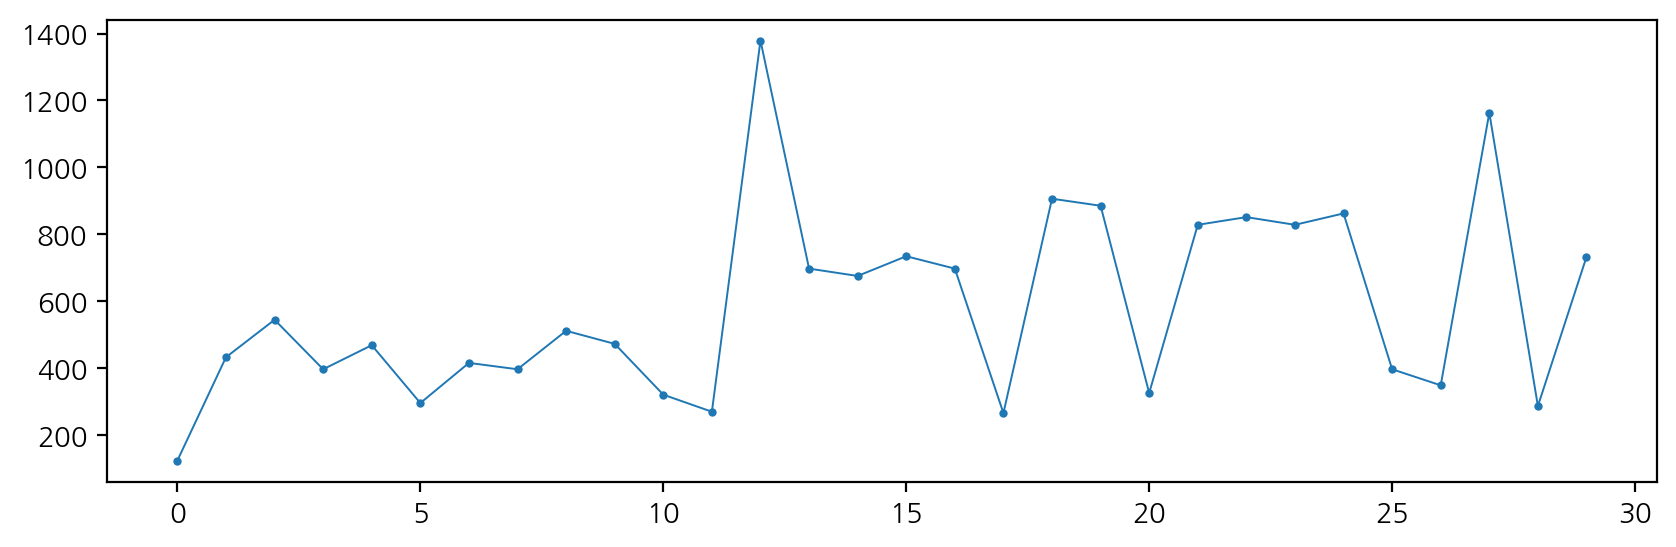

In [251]:
plt.figure(figsize=(10, 3))
plt.plot(result['예상차량수'], label='예상차량수', linewidth=0.7, marker='o', markersize=2)